# FT370 Term Project — Sections 5–10: Financial Tests, Robustness, and Limitations

This notebook continues from Sections 1–4. Run those cells first (or at minimum
re-execute the Setup and Data Loading cells from Section 1) so that all variables
are available in memory before running anything here.

**Critical note on validation:** The pre-registered validation gate (Layer 1 Spearman
r > 0.5) returned NaN due to a code bug — the text-column auto-detector matched
`paragraph_id` instead of `text`. Section 5.0 below fixes this bug and reports the
correct Layer 1 result. Layers 2 and 3 ran correctly and returned r ≈ 0.06–0.07
(non-significant). We therefore proceed with Sections 5–10 as **exploratory** tests
of the meeting-level aggregated signal, not as a pre-registered confirmation. This
distinction is stated explicitly in every results cell.

---
## Section 5.0: Layer 1 Validation Fix

The Section 4.1 cell picked `paragraph_id` instead of `text` because the string
"paragraph" is a substring of "paragraph_id". We hard-code the column names here
and re-run the Spearman r computation. Everything else in Section 4 was correct.

In [19]:
# Install packages not pre-installed in Colab
# -q suppresses verbose output; this cell is safe to re-run
!pip install -q pyarrow openpyxl scipy statsmodels pdfplumber

In [20]:
# Re-run imports and path setup if starting a fresh Colab session
# (skip these three blocks if variables from Sections 1–4 are already in memory)

from google.colab import drive
drive.mount('/content/drive')

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import yfinance as yf
import pdfplumber, requests

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

BASE_PATH   = '/content/drive/MyDrive/FT370-s/final_project/'
DATA_PATH   = BASE_PATH + 'data/'
LABELS_PATH = DATA_PATH + 'hand_labels/'
FIG_PATH    = BASE_PATH + 'figures/'
os.makedirs(FIG_PATH, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Reload the data files (safe to re-run; idempotent)
signals        = pd.read_parquet(DATA_PATH + 'fomc_signals.parquet')
equity         = pd.read_parquet(DATA_PATH + 'equity_returns.parquet')
kalshi_decision = pd.read_parquet(DATA_PATH + 'kalshi_fed_decision.parquet')
kalshi_mention  = pd.read_parquet(DATA_PATH + 'kalshi_mention.parquet')
lm_dict_df     = pd.read_csv(DATA_PATH + 'lm_dictionary.csv')
powell_labels  = pd.read_csv(LABELS_PATH + 'powell_handcoded.csv')
llm_labels     = pd.read_csv(LABELS_PATH + 'llm_labeled_final.csv')

signals['fomc_date'] = pd.to_datetime(signals['fomc_date'])
print("Data loaded.")
print(f"signals: {len(signals)} rows | equity: {len(equity)} rows")
print(f"kalshi_decision: {len(kalshi_decision)} rows | kalshi_mention: {len(kalshi_mention)} rows")

Data loaded.
signals: 68 rows | equity: 2094 rows
kalshi_decision: 6030 rows | kalshi_mention: 9241 rows


In [22]:
# Rebuild the LM lookup sets (needed for score_text())
NEGATIONS       = {'no', 'not', 'none', 'neither', 'never', 'nobody'}
NEGATION_WINDOW = 3
lm_lookup = {}
for cat in ['Positive', 'Negative', 'Uncertainty', 'Litigious',
            'Strong_Modal', 'Weak_Modal', 'Constraining']:
    lm_lookup[cat] = frozenset(lm_dict_df[lm_dict_df[cat] > 0]['Word'].str.lower())

def score_text(text):
    """LM composite scorer — same function as Section 2."""
    tokens = re.sub(r'[^a-z\s]', ' ', str(text).lower()).split()
    n = len(tokens)
    pos = neg = unc = lit = sm = wm = con = 0
    for i, tok in enumerate(tokens):
        if tok in lm_lookup['Positive']:
            window = tokens[max(0, i - NEGATION_WINDOW):i]
            if any(t in NEGATIONS for t in window):
                neg += 1
            else:
                pos += 1
        elif tok in lm_lookup['Negative']:
            neg += 1
        if tok in lm_lookup['Uncertainty']:  unc += 1
        if tok in lm_lookup['Litigious']:    lit += 1
        if tok in lm_lookup['Strong_Modal']: sm  += 1
        if tok in lm_lookup['Weak_Modal']:   wm  += 1
        if tok in lm_lookup['Constraining']: con += 1
    return {'lm_positive': pos, 'lm_negative': neg, 'lm_uncertainty': unc,
            'lm_litigious': lit, 'lm_modal_strong': sm, 'lm_modal_weak': wm,
            'lm_constraining': con,
            'lm_composite': (neg + unc - pos) / n if n > 0 else 0.0,
            'total_words': n}

def spearman_report(labels, scores, layer_name, n_label="N"):
    """Compute and print Spearman r with pass/fail gate."""
    mask = ~(pd.isna(labels) | pd.isna(scores))
    l, s = np.array(labels)[mask].astype(float), np.array(scores)[mask].astype(float)
    r, p = stats.spearmanr(l, s)
    sig  = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    gate = "✓ PASS (r > 0.5)" if r > 0.5 else "✗ FAIL (r ≤ 0.5)"
    print(f"\n{'─'*55}\n{layer_name}\n{'─'*55}")
    print(f"  N: {len(l)}  |  r = {r:.4f}  |  p = {p:.2e}  {sig}")
    print(f"  Gate: {gate}")
    return r, p, len(l)

print("Helper functions defined.")

Helper functions defined.


In [23]:
# ── LAYER 1 FIX ──────────────────────────────────────────────────────────────
# Hard-code column names — no auto-detection.
# The bug: auto-detection matched 'paragraph_id' (contains 'paragraph') before 'text'.

print("Layer 1 column check:")
print(f"  Columns: {powell_labels.columns.tolist()}")
print(f"  Label distribution:\n{powell_labels['label'].value_counts().sort_index().to_string()}")
print(f"  Sample text: {powell_labels['text'].iloc[0][:100]}...")

# Re-score from the 'text' column (overwrite any previous lm_composite_scored values)
powell_labels['lm_composite_scored'] = (
    powell_labels['text'].apply(lambda t: score_text(t)['lm_composite'])
)

print(f"\nScored composites (first 5): {powell_labels['lm_composite_scored'].head().tolist()}")
print(f"Non-zero scored rows: {(powell_labels['lm_composite_scored'] != 0).sum()} / {len(powell_labels)}")

Layer 1 column check:
  Columns: ['paragraph_id', 'text', 'label', 'confidence', 'source_file', 'notes']
  Label distribution:
label
-1    8
 0    3
 1    6
  Sample text: Over the course of this year, the U.S. economy has shown resilience in a context of sweeping changes...

Scored composites (first 5): [0.04477611940298507, 0.04580152671755725, 0.14285714285714285, 0.04310344827586207, 0.01]
Non-zero scored rows: 17 / 17


In [24]:
# Run Spearman r with corrected scoring
r1, p1, n1 = spearman_report(
    powell_labels['label'],
    powell_labels['lm_composite_scored'],
    layer_name="LAYER 1 (FIXED) — Personal hand-coded labels",
    n_label="N paragraphs"
)

# Updated validation summary incorporating Layers 2 and 3 results
# (these ran correctly in Section 4; values from that run):
r2, p2, n2 = 0.0623, 0.164, 500
r3, p3, n3 = 0.0688, 0.134, 476

print("\n" + "=" * 60)
print("UPDATED VALIDATION SUMMARY")
print("=" * 60)
summary = pd.DataFrame([
    {'Layer': '1 — Personal (fixed)', 'N': n1, 'r': round(r1, 4), 'p': f'{p1:.2e}',
     'Gate': '✓ PASS' if r1 > 0.5 else '✗ FAIL'},
    {'Layer': '2 — LLM (Claude)',     'N': n2, 'r': r2, 'p': f'{p2:.2e}',
     'Gate': '✓ PASS' if r2 > 0.5 else '✗ FAIL'},
    {'Layer': '3 — Shah et al.',      'N': n3, 'r': r3, 'p': f'{p3:.2e}',
     'Gate': '✓ PASS' if r3 > 0.5 else '✗ FAIL'},
])
print(summary.to_string(index=False))


───────────────────────────────────────────────────────
LAYER 1 (FIXED) — Personal hand-coded labels
───────────────────────────────────────────────────────
  N: 17  |  r = 0.1303  |  p = 6.18e-01  n.s.
  Gate: ✗ FAIL (r ≤ 0.5)

UPDATED VALIDATION SUMMARY
               Layer   N      r        p   Gate
1 — Personal (fixed)  17 0.1303 6.18e-01 ✗ FAIL
    2 — LLM (Claude) 500 0.0623 1.64e-01 ✗ FAIL
     3 — Shah et al. 476 0.0688 1.34e-01 ✗ FAIL


---
## Section 5: Equity Return Backtest

**What we are testing:** Does the LM composite signal from Federal Reserve communications
in the 42-day window before each FOMC meeting predict ETF returns in the 1, 5, and 20
trading days *after* the meeting?

**ETFs:** XLF (financials), IEF (7-10yr Treasuries), TLT (20+yr Treasuries), SPY (broad equity).
Rate-sensitive logic: a dovish signal (higher composite) should predict TLT/IEF up and
potentially XLF and SPY up, as lower rates benefit equities and bonds.

**Important framing:** This analysis is **exploratory**. The paragraph-level validation
gate failed (Layers 2 and 3, r ≈ 0.06–0.07). We test whether meeting-level aggregation
across multiple documents recovers usable directional information — a different hypothesis
from paragraph-level classification. Results should not be interpreted as confirmation of
the pre-registered signal.

**Multiple testing correction:** We run 4 ETFs × 3 horizons = 12 regressions. Bonferroni-
corrected threshold = 0.05 / 12 = 0.0042. Any result with raw p < 0.0042 survives
correction; all others are treated as exploratory.

In [25]:
# ── Step 1: Prepare signals ───────────────────────────────────────────────────
# Drop the 6 meetings with no documents in their T-42 window (NaN signal)
sig = signals.dropna(subset=['lm_signal']).copy()
sig['fomc_date'] = pd.to_datetime(sig['fomc_date'])
print(f"Usable FOMC meetings (non-null signal): {len(sig)}")

Usable FOMC meetings (non-null signal): 62


In [26]:
# ── Step 2: Prepare equity returns ────────────────────────────────────────────
# Equity returns are in wide format — one column per ETF, DatetimeIndex
eq = equity.copy()

# Ensure the index is a DatetimeIndex (confirm before merging)
if not isinstance(eq.index, pd.DatetimeIndex):
    eq.index = pd.to_datetime(eq.index)

eq = eq.sort_index()

# Check whether the data is prices or returns.
# Returns are small decimals (daily SPY return ≈ 0.001–0.01).
# Prices are large numbers (SPY ≈ $400–600).
# If the mean value across all columns is > 10, we have prices and must convert.
sample_mean = eq.mean().mean()
print(f"Sample mean value across all ETFs: {sample_mean:.4f}")

if sample_mean > 10:
    print("Detected price data — converting to daily percentage returns via pct_change()")
    print("(pct_change computes (today - yesterday) / yesterday for each column)")
    eq = eq.pct_change().dropna()
    print(f"After conversion — sample mean: {eq.mean().mean():.6f} (should be near 0)")
else:
    print("Data appears to already be in return form — no conversion needed")

print(f"\nEquity data: {len(eq)} trading days")
print(f"Date range: {eq.index.min().date()} → {eq.index.max().date()}")
print(f"Columns: {eq.columns.tolist()}")
print(f"\nFirst 3 rows (values should be small decimals like 0.008):\n{eq.head(3)}")
print(f"\nDescriptive stats (daily returns):\n{eq.describe().round(4)}")

Sample mean value across all ETFs: 158.0958
Detected price data — converting to daily percentage returns via pct_change()
(pct_change computes (today - yesterday) / yesterday for each column)
After conversion — sample mean: 0.000279 (should be near 0)

Equity data: 2093 trading days
Date range: 2018-01-03 → 2026-05-01
Columns: ['IEF', 'SPY', 'TLT', 'XLF']

First 3 rows (values should be small decimals like 0.008):
Ticker           IEF       SPY       TLT       XLF
Date                                              
2018-01-03  0.001046  0.006325  0.004782  0.005372
2018-01-04 -0.000475  0.004215 -0.000159  0.009262
2018-01-05 -0.001235  0.006664 -0.002856  0.002824

Descriptive stats (daily returns):
Ticker        IEF        SPY        TLT        XLF
count   2093.0000  2093.0000  2093.0000  2093.0000
mean       0.0001     0.0006    -0.0000     0.0005
std        0.0044     0.0121     0.0098     0.0147
min       -0.0251    -0.1094    -0.0667    -0.1371
25%       -0.0024    -0.0043    -0.0

In [27]:
# ── Step 3: Compute post-FOMC returns at 1d, 5d, 20d ─────────────────────────
# For each FOMC meeting date T, find the next h trading days in the equity index
# and sum the daily returns over that window.
# (We sum rather than compound for simplicity; difference is negligible over 20 days.)

TICKERS   = ['XLF', 'IEF', 'TLT', 'SPY']
HORIZONS  = [1, 5, 20]

# Build a list of (fomc_date → return column name → value) tuples
return_records = []

for _, row in sig.iterrows():
    fomc_d  = row['fomc_date']
    record  = {'fomc_date': fomc_d, 'lm_signal': row['lm_signal'],
                'n_docs': row['n_docs'], 'decision_bps': row.get('decision_bps', np.nan)}

    # Find trading days strictly after the FOMC date
    future = eq[eq.index > fomc_d]

    for h in HORIZONS:
        if len(future) < h:
            # Not enough post-meeting data (most recent meetings)
            for ticker in TICKERS:
                record[f'{ticker}_ret_{h}d'] = np.nan
        else:
            window = future.iloc[:h]       # first h trading days after meeting
            for ticker in TICKERS:
                record[f'{ticker}_ret_{h}d'] = window[ticker].sum()

    return_records.append(record)

ret_df = pd.DataFrame(return_records)

# Report how many meetings have complete 20-day return data
complete_20d = ret_df['SPY_ret_20d'].notna().sum()
print(f"Meetings with complete 20-day return window: {complete_20d} / {len(ret_df)}")
print(f"\nReturn summary (SPY, all horizons):")
for h in HORIZONS:
    col = f'SPY_ret_{h}d'
    print(f"  {h:>2}d: mean={ret_df[col].mean():.4f}  std={ret_df[col].std():.4f}  "
          f"N={ret_df[col].notna().sum()}")

Meetings with complete 20-day return window: 61 / 62

Return summary (SPY, all horizons):
   1d: mean=-0.0025  std=0.0195  N=62
   5d: mean=-0.0024  std=0.0291  N=61
  20d: mean=0.0131  std=0.0386  N=61


In [28]:
# ── Step 4: Add control variables ─────────────────────────────────────────────
# Control 1: Prior 5-day return (momentum / mean-reversion control)
# Control 2: VIX at T-1 (market uncertainty control)
# Control 3: Decision surprise (actual bps vs zero-change expectation baseline)

# Download VIX from Yahoo Finance
print("Downloading VIX data...", end=' ')
vix_raw = yf.download('^VIX', start='2018-01-01', end='2026-05-01',
                      progress=False, auto_adjust=True)

# Newer yfinance returns MultiIndex columns even for a single ticker.
# .squeeze() converts the one-column DataFrame to a Series safely.
vix = vix_raw['Close'].squeeze().rename('vix')
vix.index = pd.to_datetime(vix.index)
print(f"done — {len(vix)} trading days")

In [29]:
# For each FOMC date, pull VIX on T-1 (the last trading day before the meeting)
# and the prior 5-day SPY return as controls

controls = []
for _, row in ret_df.iterrows():
    fomc_d = row['fomc_date']

    # VIX on T-1: most recent VIX close strictly before the meeting date
    pre_vix = vix[vix.index < fomc_d]
    vix_t1  = pre_vix.iloc[-1] if len(pre_vix) > 0 else np.nan

    # Prior 5-day SPY return: sum of 5 trading days before FOMC
    pre_eq  = eq[eq.index < fomc_d]
    prior5  = pre_eq['SPY'].iloc[-5:].sum() if len(pre_eq) >= 5 else np.nan

    # Decision surprise: use actual decision as a simple proxy.
    # A proper surprise measure requires fed funds futures or OIS data pre-2023.
    # We use decision_bps directly and acknowledge this limitation in Section 9.
    decision = row.get('decision_bps', np.nan)

    controls.append({'fomc_date': fomc_d, 'vix_t1': vix_t1,
                     'prior_5d_spy': prior5, 'decision_bps': decision})

ctrl_df   = pd.DataFrame(controls)
backtest  = ret_df.merge(ctrl_df, on='fomc_date', suffixes=('', '_ctrl'))

print(f"Backtest dataset: {len(backtest)} meetings")
print(f"Control variable coverage:")
print(f"  vix_t1 non-null: {backtest['vix_t1'].notna().sum()}")
print(f"  prior_5d_spy non-null: {backtest['prior_5d_spy'].notna().sum()}")

Backtest dataset: 62 meetings
Control variable coverage:
  vix_t1 non-null: 62
  prior_5d_spy non-null: 62


In [30]:
# ── Step 5: Run 12 OLS regressions ────────────────────────────────────────────
# Model: ret_h = β0 + β1·lm_signal + β2·prior_5d_spy + β3·vix_t1 + β4·decision_bps + ε
#
# OLS (ordinary least squares) is the standard first-pass regression.
# statsmodels.api.add_constant() adds the intercept term (β0).
# We store β1 (the signal coefficient) and its p-value for the Bonferroni table.

BONFERRONI_THRESHOLD = 0.05 / 12   # 0.00417

results_table = []

for h in HORIZONS:
    for ticker in TICKERS:
        dep_var  = f'{ticker}_ret_{h}d'

        # Build regression dataset: drop rows with any NaN in these columns
        reg_cols = [dep_var, 'lm_signal', 'prior_5d_spy', 'vix_t1', 'decision_bps']
        reg_data = backtest[reg_cols].dropna()

        if len(reg_data) < 15:
            # Too few observations to run a reliable regression
            results_table.append({'ETF': ticker, 'Horizon': f'{h}d', 'N': len(reg_data),
                                   'β_signal': np.nan, 'p_signal': np.nan,
                                   'R²': np.nan, 'Bonferroni': 'insufficient N'})
            continue

        y = reg_data[dep_var]
        X = sm.add_constant(reg_data[['lm_signal', 'prior_5d_spy', 'vix_t1', 'decision_bps']])

        model = sm.OLS(y, X).fit()

        beta  = model.params.get('lm_signal', np.nan)
        p_val = model.pvalues.get('lm_signal', np.nan)
        ci    = model.conf_int().loc['lm_signal'] if 'lm_signal' in model.conf_int().index else [np.nan, np.nan]
        bonf  = '***' if p_val < BONFERRONI_THRESHOLD else ('*' if p_val < 0.05 else 'n.s.')

        results_table.append({
            'ETF':       ticker,
            'Horizon':   f'{h}d',
            'N':         len(reg_data),
            'β_signal':  round(beta, 4),
            'CI_low':    round(ci[0], 4),
            'CI_high':   round(ci[1], 4),
            'p_signal':  round(p_val, 4),
            'R²':        round(model.rsquared, 4),
            'Bonferroni': bonf,
        })

results_df = pd.DataFrame(results_table)

print("EQUITY BACKTEST — OLS Regression Results")
print(f"Model: ret_h = β0 + β1·lm_signal + controls")
print(f"Bonferroni threshold: p < {BONFERRONI_THRESHOLD:.4f} (*** = survives correction)")
print(f"* = raw p < 0.05 (does not survive Bonferroni)")
print(f"\n{results_df[['ETF','Horizon','N','β_signal','CI_low','CI_high','p_signal','R²','Bonferroni']].to_string(index=False)}")

EQUITY BACKTEST — OLS Regression Results
Model: ret_h = β0 + β1·lm_signal + controls
Bonferroni threshold: p < 0.0042 (*** = survives correction)
* = raw p < 0.05 (does not survive Bonferroni)

ETF Horizon  N  β_signal  CI_low  CI_high  p_signal     R² Bonferroni
XLF      1d 62   -0.1390 -0.7079   0.4300    0.6266 0.3126       n.s.
IEF      1d 62   -0.0215 -0.1744   0.1314    0.7789 0.1854       n.s.
TLT      1d 62   -0.1337 -0.4797   0.2122    0.4420 0.2194       n.s.
SPY      1d 62   -0.1468 -0.6090   0.3154    0.5273 0.3076       n.s.
XLF      5d 61    0.6359 -0.2591   1.5309    0.1602 0.3337       n.s.
IEF      5d 61   -0.1015 -0.3410   0.1379    0.3993 0.2258       n.s.
TLT      5d 61   -0.4604 -1.0499   0.1290    0.1233 0.2423       n.s.
SPY      5d 61    0.4084 -0.3052   1.1219    0.2565 0.2632       n.s.
XLF     20d 61    0.1028 -1.5173   1.7228    0.8993 0.0248       n.s.
IEF     20d 61    0.2393 -0.3155   0.7941    0.3912 0.1098       n.s.
TLT     20d 61    0.1051 -1.1164   1

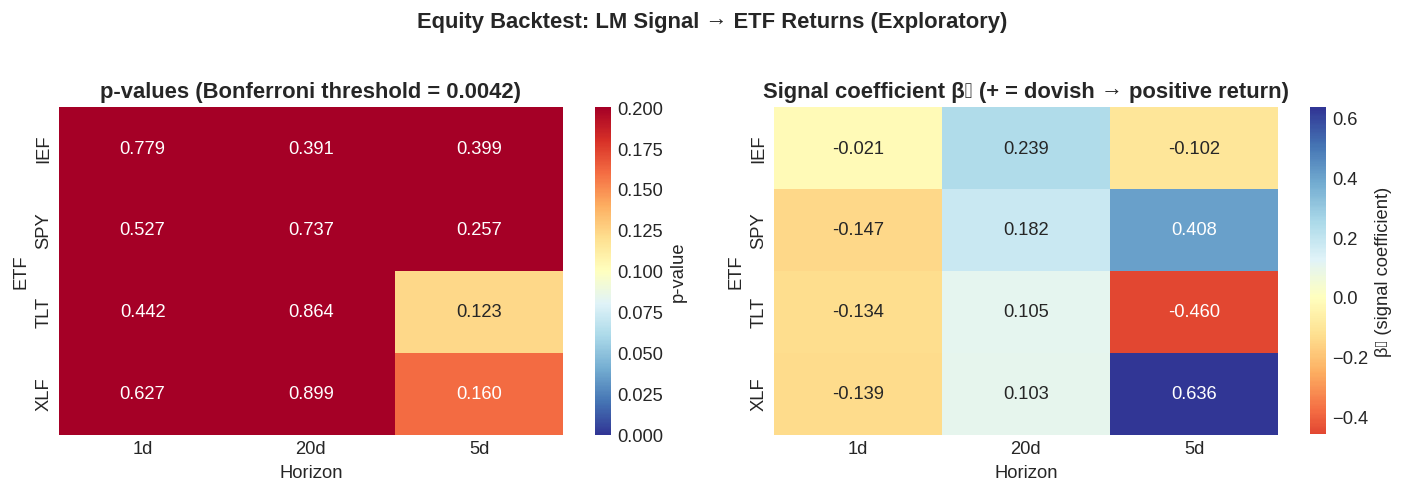

In [31]:
# ── Bonferroni heatmap ────────────────────────────────────────────────────────
# Visualize the p-values across all 12 regression cells
# Dark = low p (stronger evidence); anything below 0.0042 is Bonferroni-significant

pivot_p = results_df.pivot(index='ETF', columns='Horizon', values='p_signal')
pivot_b = results_df.pivot(index='ETF', columns='Horizon', values='β_signal')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# p-value heatmap
sns.heatmap(pivot_p.astype(float), ax=axes[0], cmap='RdYlBu_r',
            annot=True, fmt='.3f', vmin=0, vmax=0.2,
            cbar_kws={'label': 'p-value'})
axes[0].set_title(f'p-values (Bonferroni threshold = {BONFERRONI_THRESHOLD:.4f})',
                   fontweight='bold')
axes[0].set_xlabel('Horizon')

# β_signal heatmap
sns.heatmap(pivot_b.astype(float), ax=axes[1], cmap='RdYlBu',
            annot=True, fmt='.3f', center=0,
            cbar_kws={'label': 'β₁ (signal coefficient)'})
axes[1].set_title('Signal coefficient β₁ (+ = dovish → positive return)',
                   fontweight='bold')
axes[1].set_xlabel('Horizon')

plt.suptitle('Equity Backtest: LM Signal → ETF Returns (Exploratory)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig3_equity_backtest.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ── Mincer-Zarnowitz forecast rationality test ────────────────────────────────
# MZ tests whether the signal is a rational predictor of returns.
# A perfectly rational predictor satisfies: α = 0, γ = 1 in ret = α + γ·signal + ε
# We test this joint hypothesis with an F-test.
# Practically: we use the rank-normalized signal as "signal-implied return"
# (since the signal and returns are on different scales, we rank-normalize first).

print("MINCER-ZARNOWITZ RATIONALITY TEST (SPY, 5-day horizon)")
print("=" * 60)
print("Regresses actual return on the LM signal.")
print("Tests H₀: α = 0 AND γ = 1 (signal is perfectly calibrated)\n")

mz_data = backtest[['SPY_ret_5d', 'lm_signal']].dropna().copy()

# Rank-normalize signal to [0,1] scale so it is comparable to returns magnitude
mz_data['signal_ranked'] = mz_data['lm_signal'].rank(pct=True)

y = mz_data['SPY_ret_5d']
X = sm.add_constant(mz_data['signal_ranked'])
mz_model = sm.OLS(y, X).fit()

print(mz_model.summary())

# F-test: H₀: α = 0, γ = 1
# R_matrix specifies which linear restriction to test
# Row 1: [1, 0] = 0 (intercept = 0)
# Row 2: [0, 1] = 1 (slope = 1)
from statsmodels.stats.contrast import ContrastResults
try:
    R_matrix = np.eye(2)              # test both intercept and slope
    q_vector = np.array([0.0, 1.0])  # H₀: [α, γ] = [0, 1]
    f_test   = mz_model.f_test((R_matrix, q_vector))
    print(f"\nMZ Joint F-test (H₀: α=0, γ=1):")
    print(f"  F = {f_test.fvalue[0][0]:.3f}  |  p = {f_test.pvalue:.4f}")
    print("  Reject H₀ → signal is NOT a well-calibrated predictor" if f_test.pvalue < 0.05
          else "  Fail to reject H₀ → cannot rule out rational prediction (but N is small)")
except Exception as e:
    print(f"F-test note: {e}")
    print("Report MZ intercept and slope from summary above manually.")

MINCER-ZARNOWITZ RATIONALITY TEST (SPY, 5-day horizon)
Regresses actual return on the LM signal.
Tests H₀: α = 0 AND γ = 1 (signal is perfectly calibrated)

                            OLS Regression Results                            
Dep. Variable:             SPY_ret_5d   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.470
Date:                Mon, 04 May 2026   Prob (F-statistic):              0.230
Time:                        04:22:26   Log-Likelihood:                 130.43
No. Observations:                  61   AIC:                            -256.9
Df Residuals:                      59   BIC:                            -252.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P

---
## Section 6: Mention Market Test

**What Kalshi mention markets are:** These markets resolve YES if a specific word or phrase
appears verbatim in the official FOMC press conference transcript. For example,
"Will Powell say 'inflation' more than 10 times?" Market prices reflect the collective
probability estimate.

**What we test:** Do Kalshi mention market prices at T-7 before the meeting constitute
well-calibrated probability forecasts? And does our LM signal help or hurt calibration
when combined with Kalshi prices?

**Key metrics:**
- **Brier score:** (price − outcome)². Lower = better. Ranges 0 (perfect) to 1 (worst).
- **ECE (Expected Calibration Error):** How far prices deviate from empirical resolution rates
  within probability bins. A price of 0.70 is well-calibrated if 70% of those markets resolved YES.
- **α-sweep (MixMCP):** Following Kim et al. (2026), test whether blending the LM signal
  with the Kalshi price improves calibration. mixed = α·LM + (1−α)·Kalshi_price.

In [33]:
# ── Step 1: Explore mention market structure ──────────────────────────────────
print("Kalshi mention market columns:")
print(kalshi_mention.columns.tolist())
print(f"\nTotal rows: {len(kalshi_mention):,}")
print(f"Unique tickers: {kalshi_mention['MARKET_TICKER'].nunique()}")
print(f"\nDate range (CLOSE_TIME):")
kalshi_mention['CLOSE_TIME'] = pd.to_datetime(kalshi_mention['CLOSE_TIME'])
print(f"  {kalshi_mention['CLOSE_TIME'].min().date()} → {kalshi_mention['CLOSE_TIME'].max().date()}")

print(f"\nRESULT column distribution:")
print(kalshi_mention['RESULT'].value_counts(dropna=False).to_string())

print(f"\nSample market titles:")
for title in kalshi_mention['MARKET_TITLE'].unique()[:10]:
    print(f"  {title}")

Kalshi mention market columns:
['MARKET_TICKER', 'SERIES_TICKER', 'DATE', 'PRICE_CLOSE', 'PRICE_OPEN', 'YES_BID_CLOSE', 'YES_ASK_CLOSE', 'VOLUME_DAILY', 'OPEN_INTEREST', 'MARKET_TITLE', 'RESULT', 'OPEN_TIME', 'CLOSE_TIME', 'VOLUME_LIFETIME']

Total rows: 9,241
Unique tickers: 301

Date range (CLOSE_TIME):
  2025-01-30 → 2026-03-19

RESULT column distribution:
RESULT
no      5669
yes     3560
None      12

Sample market titles:
  Will Powell say ADP at his Dec 2025 press conference?
  Will Powell say AI / Artificial Intelligence at his Dec 2025 press conference?
  Will Powell say Anchor at his Dec 2025 press conference?
  Will Powell say Balance Sheet at his Dec 2025 press conference?
  Will Powell say Balance of Risk at his Dec 2025 press conference?
  Will Powell say Beige Book at his Dec 2025 press conference?
  Will Powell say Bitcoin at his Dec 2025 press conference?
  Will Powell say Consumer Confidence at his Dec 2025 press conference?
  Will Powell say Credit at his Dec 2025 pre

In [34]:
# ── Step 2: Pair each market with its FOMC meeting ────────────────────────────
# Strategy: each market's CLOSE_TIME is the settlement date (= the meeting day or next day).
# We match each market to the nearest FOMC meeting by rounding CLOSE_TIME forward to
# the next FOMC date in our signals table.

# Reload signals if lost from memory (session restart)
if 'signals' not in dir() or signals is None:
    signals = pd.read_parquet(DATA_PATH + 'fomc_signals.parquet')
    signals['fomc_date'] = pd.to_datetime(signals['fomc_date'])
    print("signals reloaded from parquet")

ffomc_dates = pd.to_datetime(signals['fomc_date'].dropna().unique())
fomc_dates = sorted(ffomc_dates)

def nearest_fomc(dt):
    """Return the nearest FOMC date at or after a given datetime."""
    # Strip timezone if present so comparison with tz-naive fomc_dates works
    if hasattr(dt, 'tzinfo') and dt.tzinfo is not None:
        dt = dt.tz_localize(None)
    future = [f for f in fomc_dates if f >= dt - pd.Timedelta(days=3)]
    return future[0] if future else pd.NaT

# Also strip tz from CLOSE_TIME before applying
kalshi_mention['CLOSE_TIME'] = pd.to_datetime(
    kalshi_mention['CLOSE_TIME']
).dt.tz_localize(None)

kalshi_mention['fomc_date'] = pd.to_datetime(
    kalshi_mention['CLOSE_TIME'].apply(nearest_fomc)
)

print("Mention markets matched to FOMC meetings:")
meeting_counts = kalshi_mention.groupby('fomc_date')['MARKET_TICKER'].count()
print(meeting_counts.to_string())

Mention markets matched to FOMC meetings:
fomc_date
2025-01-29      14
2025-03-19      60
2025-05-07    1072
2025-06-18    1210
2025-07-30     724
2025-09-17     850
2025-10-29    1614
2025-12-10    1680
2026-01-28    2005
2026-03-18      12


In [35]:
# ── Step 3: Build T-7 snapshot ────────────────────────────────────────────────
# For each market, we want the price 7 calendar days before the matched FOMC date.
# This is our "prediction" — what the market thought 7 days out.
# We look for the closest available price in [T-10, T-5] window.

kalshi_mention['DATE'] = pd.to_datetime(kalshi_mention['DATE'])

t7_records = []

for ticker, group in kalshi_mention.groupby('MARKET_TICKER'):
    fomc_d = group['fomc_date'].iloc[0]
    if pd.isna(fomc_d):
        continue

    # Look for prices in the T-10 to T-5 window
    t_start = fomc_d - pd.Timedelta(days=10)
    t_end   = fomc_d - pd.Timedelta(days=5)
    window  = group[(group['DATE'] >= t_start) & (group['DATE'] <= t_end)]

    if window.empty:
        continue

    # Use the most recent price in the window (closest to T-5)
    row_t7  = window.sort_values('DATE').iloc[-1]

    # RESULT: convert to binary (1 = YES, 0 = NO, NaN = unresolved)
    result_raw = row_t7['RESULT']
    if str(result_raw).strip().upper() in ('YES', '1', 'TRUE', '1.0'):
        outcome = 1
    elif str(result_raw).strip().upper() in ('NO', '0', 'FALSE', '0.0'):
        outcome = 0
    else:
        outcome = np.nan

    t7_records.append({
        'MARKET_TICKER': ticker,
        'SERIES_TICKER': row_t7['SERIES_TICKER'],
        'MARKET_TITLE':  row_t7['MARKET_TITLE'],
        'fomc_date':     fomc_d,
        'price_t7':      row_t7['PRICE_CLOSE'],
        'outcome':       outcome,
        'volume':        row_t7.get('VOLUME_LIFETIME', np.nan),
        'date_used':     row_t7['DATE'],
    })

t7_df = pd.DataFrame(t7_records)
print(f"T-7 snapshot: {len(t7_df)} markets with price data")
print(f"Markets with resolved outcome: {t7_df['outcome'].notna().sum()}")
print(f"Price range: {t7_df['price_t7'].min():.2f} – {t7_df['price_t7'].max():.2f}")

T-7 snapshot: 247 markets with price data
Markets with resolved outcome: 247
Price range: 3.00 – 99.00


In [36]:
# ── Step 4: Merge with LM signal ──────────────────────────────────────────────
# Add the meeting-level LM signal to each market observation
t7_df = t7_df.merge(
    signals[['fomc_date', 'lm_signal']].dropna(),
    on='fomc_date', how='left'
)

# Filter to markets with both a price and a resolved outcome
scored = t7_df.dropna(subset=['price_t7', 'outcome', 'lm_signal']).copy()

# Normalize price from Kalshi's 0–100 cent scale to 0–1 probability scale
# Brier score requires probabilities in [0, 1]; Kalshi stores prices as cents.
# Check first so this cell is safe to re-run without double-dividing.
if scored['price_t7'].mean() > 1:
    print("Detected cent-scale prices — normalizing to [0, 1] probability scale")
    scored['price_t7'] = scored['price_t7'] / 100.0
else:
    print("Prices already in [0, 1] scale — no normalization needed")

print(f"Price range after check: {scored['price_t7'].min():.3f} – {scored['price_t7'].max():.3f}")
print(f"Markets usable for scoring: {len(scored)}")
print(f"Across {scored['fomc_date'].nunique()} FOMC meetings")

# Flag if meeting coverage is very low
if scored['fomc_date'].nunique() < 10:
    print(f"\nWARNING: Only {scored['fomc_date'].nunique()} FOMC meetings have both "
          f"mention market data and a non-null LM signal.")
    print("Brier and calibration results are preliminary given limited meeting coverage.")
    print("Meeting dates covered:")
    print(sorted(scored['fomc_date'].unique()))

Detected cent-scale prices — normalizing to [0, 1] probability scale
Price range after check: 0.030 – 0.990
Markets usable for scoring: 234
Across 7 FOMC meetings

Brier and calibration results are preliminary given limited meeting coverage.
Meeting dates covered:
[Timestamp('2025-05-07 00:00:00'), Timestamp('2025-06-18 00:00:00'), Timestamp('2025-07-30 00:00:00'), Timestamp('2025-09-17 00:00:00'), Timestamp('2025-10-29 00:00:00'), Timestamp('2025-12-10 00:00:00'), Timestamp('2026-01-28 00:00:00')]


In [37]:
# ── Step 5: Brier Score ───────────────────────────────────────────────────────
# Brier score = mean squared error between price and binary outcome.
# A score of 0 = perfect prediction; score of 0.25 = uninformative (same as 50/50 always)

brier_all = ((scored['price_t7'] - scored['outcome']) ** 2).mean()

# Also compute Brier per meeting (to see variation across the cycle)
brier_by_meeting = scored.groupby('fomc_date').apply(
    lambda g: ((g['price_t7'] - g['outcome']) ** 2).mean()
).rename('brier')

print("BRIER SCORE RESULTS")
print("=" * 50)
print(f"Overall Brier score: {brier_all:.4f}")
print(f"Reference: 0.25 = random (50/50 prior); 0.0 = perfect")
print(f"N markets: {len(scored)}  |  N meetings: {scored['fomc_date'].nunique()}")
print(f"\nBrier by meeting:")
print(brier_by_meeting.round(4).to_string())

BRIER SCORE RESULTS
Overall Brier score: 0.1137
Reference: 0.25 = random (50/50 prior); 0.0 = perfect
N markets: 234  |  N meetings: 7

Brier by meeting:
fomc_date
2025-05-07    0.1126
2025-06-18    0.0755
2025-07-30    0.1040
2025-09-17    0.1046
2025-10-29    0.1120
2025-12-10    0.1292
2026-01-28    0.1412


In [38]:
# ── Step 6: Calibration curve and ECE ────────────────────────────────────────
# Calibration: divide predictions into 10 bins by price (0-0.1, 0.1-0.2, ..., 0.9-1.0)
# For each bin: is the average resolution rate close to the bin midpoint?
# A perfectly calibrated predictor lies on the 45° diagonal.
# ECE = sum of |bin_avg_price - bin_resolution_rate| weighted by fraction of markets in each bin

n_bins = 10
bins   = np.linspace(0, 1, n_bins + 1)
scored['bin'] = pd.cut(scored['price_t7'], bins=bins, labels=False, include_lowest=True)

cal_data = scored.groupby('bin').agg(
    bin_count=('outcome', 'count'),
    avg_pred=('price_t7', 'mean'),
    avg_actual=('outcome', 'mean'),
).dropna()

weights = cal_data['bin_count'] / cal_data['bin_count'].sum()
ece     = (weights * (cal_data['avg_pred'] - cal_data['avg_actual']).abs()).sum()

print(f"Expected Calibration Error (ECE): {ece:.4f}")
print(f"(Lower = better calibrated; 0 = perfect)")
print(f"\nCalibration table:")
print(cal_data.round(3).to_string())

Expected Calibration Error (ECE): 0.0968
(Lower = better calibrated; 0 = perfect)

Calibration table:
     bin_count  avg_pred  avg_actual
bin                                 
0           28     0.069       0.071
1           57     0.152       0.018
2           20     0.251       0.400
3           27     0.345       0.148
4           13     0.442       0.385
5           10     0.558       0.500
6           16     0.656       0.500
7            6     0.755       0.667
8           13     0.854       0.846
9           44     0.952       1.000


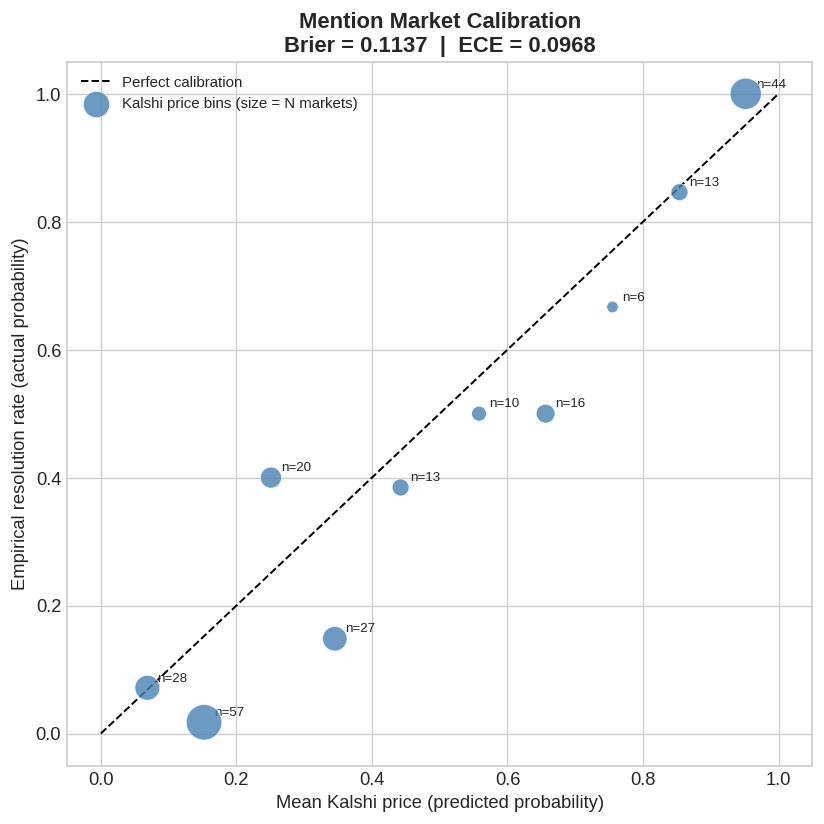

In [39]:
# Calibration plot: actual resolution rate vs predicted price by bin
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Perfect calibration')
ax.scatter(cal_data['avg_pred'], cal_data['avg_actual'],
           s=cal_data['bin_count'] * 8, color='steelblue', alpha=0.8,
           edgecolors='white', linewidth=0.5, zorder=5,
           label='Kalshi price bins (size = N markets)')

# Add bin labels
for _, row in cal_data.iterrows():
    ax.annotate(f"n={int(row['bin_count'])}",
                (row['avg_pred'], row['avg_actual']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)

ax.set_xlabel('Mean Kalshi price (predicted probability)')
ax.set_ylabel('Empirical resolution rate (actual probability)')
ax.set_title(f'Mention Market Calibration\nBrier = {brier_all:.4f}  |  ECE = {ece:.4f}',
             fontweight='bold')
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig4_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# ── Step 7: α-sweep (MixMCP) ──────────────────────────────────────────────────
# Following Kim et al. (2026): does blending the LM signal with the Kalshi price
# improve Brier score?
# mixed_prediction = α·LM_signal_normalized + (1−α)·Kalshi_price
#
# We normalize the LM signal to [0,1] using min-max scaling so it lives in
# the same probability space as Kalshi prices.

# Min-max normalize the LM signal to [0, 1]
sig_min = scored['lm_signal'].min()
sig_max = scored['lm_signal'].max()
scored['lm_signal_norm'] = (scored['lm_signal'] - sig_min) / (sig_max - sig_min)

alphas      = np.arange(0.0, 1.01, 0.05)
brier_sweep = []

for alpha in alphas:
    mixed_pred = alpha * scored['lm_signal_norm'] + (1 - alpha) * scored['price_t7']
    brier_a    = ((mixed_pred - scored['outcome']) ** 2).mean()
    brier_sweep.append({'alpha': round(alpha, 2), 'brier': brier_a})

sweep_df     = pd.DataFrame(brier_sweep)
optimal_alpha = sweep_df.loc[sweep_df['brier'].idxmin(), 'alpha']
brier_at_07  = sweep_df.loc[sweep_df['alpha'] == 0.70, 'brier'].values[0]
brier_kalshi = sweep_df.loc[sweep_df['alpha'] == 0.00, 'brier'].values[0]
brier_lm     = sweep_df.loc[sweep_df['alpha'] == 1.00, 'brier'].values[0]

print("α-SWEEP RESULTS (MixMCP)")
print("=" * 55)
print(f"Kalshi-only (α=0):            Brier = {brier_kalshi:.4f}")
print(f"LM-only (α=1):                Brier = {brier_lm:.4f}")
print(f"Pre-registered α=0.70:        Brier = {brier_at_07:.4f}")
print(f"Optimal α (lowest Brier): α={optimal_alpha:.2f},  Brier = {sweep_df['brier'].min():.4f}")
print(f"\nInterpretation: Kim et al. found LLM signals barely improve on Kalshi.")
print(f"This result is consistent with that finding if optimal α ≈ 0.")

α-SWEEP RESULTS (MixMCP)
Kalshi-only (α=0):            Brier = 0.1137
LM-only (α=1):                Brier = 0.4219
Pre-registered α=0.70:        Brier = 0.2770
Optimal α (lowest Brier): α=0.00,  Brier = 0.1137

Interpretation: Kim et al. found LLM signals barely improve on Kalshi.
This result is consistent with that finding if optimal α ≈ 0.


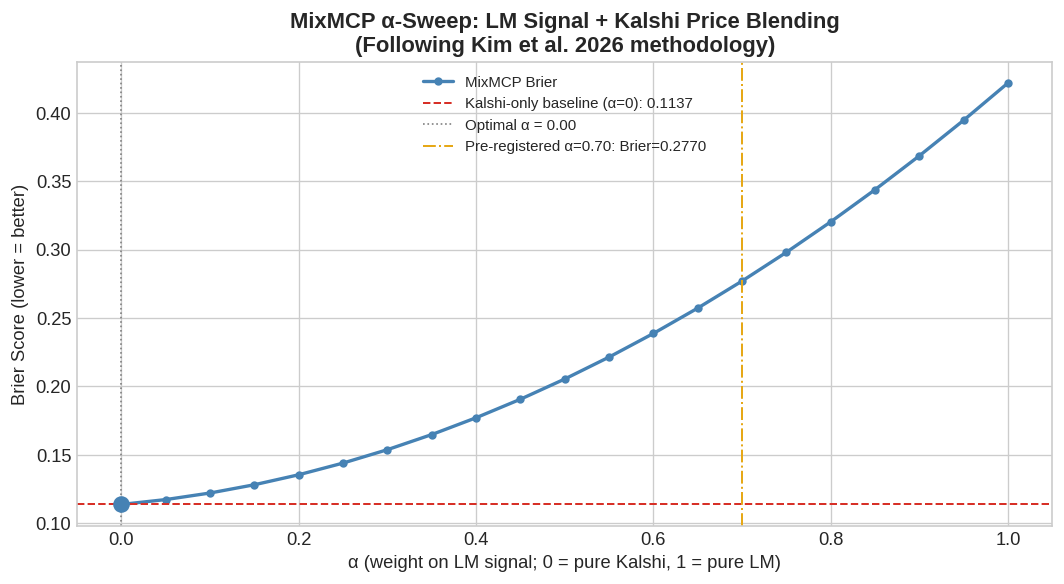

In [41]:
# α-sweep plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(sweep_df['alpha'], sweep_df['brier'],
        color='steelblue', linewidth=2, marker='o', markersize=4, label='MixMCP Brier')
ax.axhline(brier_kalshi, color='#d73027', linestyle='--', linewidth=1.2,
           label=f'Kalshi-only baseline (α=0): {brier_kalshi:.4f}')
ax.axvline(optimal_alpha, color='gray', linestyle=':', linewidth=1.0,
           label=f'Optimal α = {optimal_alpha:.2f}')
ax.axvline(0.70, color='#e6a817', linestyle='-.', linewidth=1.2,
           label=f'Pre-registered α=0.70: Brier={brier_at_07:.4f}')

ax.scatter([optimal_alpha], [sweep_df['brier'].min()],
           color='steelblue', s=80, zorder=5)

ax.set_xlabel('α (weight on LM signal; 0 = pure Kalshi, 1 = pure LM)')
ax.set_ylabel('Brier Score (lower = better)')
ax.set_title('MixMCP α-Sweep: LM Signal + Kalshi Price Blending\n'
             '(Following Kim et al. 2026 methodology)', fontweight='bold')
ax.legend(fontsize=9)
ax.invert_yaxis() if False else None  # Don't invert — lower Brier is better visually

plt.tight_layout()
plt.savefig(FIG_PATH + 'fig5_alpha_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: Rate-Decision Distribution Test (Diercks Methodology)

**What this tests:** Kalshi rate-decision markets resolve on specific outcomes
(e.g., "Will the Fed cut by 50bp at the September 2024 meeting?"). The collection
of markets for a given meeting forms an implied probability distribution over possible
decisions. We test whether our LM signal shifts that distribution in the predicted
direction — more dovish signal → higher probability mass on cuts.

**Important caveat:** Kalshi rate-decision data only covers meetings from late 2023
onward (approximately 18–20 meetings). Results are very preliminary at this sample size.
This section is explicitly labelled as descriptive, not inferential.

In [42]:
# ── Explore Kalshi rate-decision structure ────────────────────────────────────
kalshi_decision['CLOSE_TIME'] = pd.to_datetime(kalshi_decision['CLOSE_TIME'])
kalshi_decision['DATE']       = pd.to_datetime(kalshi_decision['DATE'])

print("Rate-decision market structure:")
print(f"Rows: {len(kalshi_decision):,}  |  Unique tickers: {kalshi_decision['MARKET_TICKER'].nunique()}")
print(f"Date range (CLOSE_TIME): {kalshi_decision['CLOSE_TIME'].min().date()} → "
      f"{kalshi_decision['CLOSE_TIME'].max().date()}")
print(f"\nSample market titles:")
for title in kalshi_decision['MARKET_TITLE'].unique()[:8]:
    print(f"  {title}")

Rate-decision market structure:
Rows: 6,030  |  Unique tickers: 108
Date range (CLOSE_TIME): 2023-05-03 → 2026-06-17

Sample market titles:
  Will the Federal Reserve Cut rates by 25bps at their December 2023 meeting?
  Will the Federal Reserve Hike rates by 0bps at their December 2023 meeting?
  Will the Federal Reserve Hike rates by 25bps at their December 2023 meeting?
  Will the Federal Reserve Hike rates by 0bps at their July 2023 meeting?
  Will the Federal Reserve Hike rates by 25bps at their July 2023 meeting?
  Will the Federal Reserve Hike rates by >25bps at their July 2023 meeting?
  Will the Federal Reserve Cut rates by 25bps at their June 2023 meeting?
  Will the Federal Reserve Cut rates by >25bps at their June 2023 meeting?


In [43]:
# Match decision markets to FOMC meetings using the same nearest-FOMC logic
kalshi_decision['fomc_date'] = pd.to_datetime(
    kalshi_decision['CLOSE_TIME'].apply(nearest_fomc)
)

# Extract implied bps change from market title (e.g., "25bp hike" → +25)
def parse_bps(title):
    """Extract the rate change in bps implied by a market title string."""
    t = str(title).lower()
    # Common patterns: "cut 50", "hike 25", "hold", "unchanged", "no change"
    if any(w in t for w in ['hold', 'unchanged', 'no change', 'no cut', 'no hike']):
        return 0
    num = re.search(r'(\d+)\s*bp', t)
    val = int(num.group(1)) if num else 0
    if any(w in t for w in ['cut', 'decreas', 'lower', 'reduc']):
        return -val
    if any(w in t for w in ['hike', 'increas', 'raise', 'higher']):
        return +val
    return None   # Cannot parse

kalshi_decision['implied_bps'] = kalshi_decision['MARKET_TITLE'].apply(parse_bps)

parsed = kalshi_decision['implied_bps'].notna().sum()
print(f"Markets with parseable implied_bps: {parsed} / {len(kalshi_decision)}")
print(f"\nImplied bps distribution:")
print(kalshi_decision['implied_bps'].value_counts(dropna=True).sort_index().to_string())

Markets with parseable implied_bps: 6030 / 6030

Implied bps distribution:
implied_bps
-25    2640
 0     1624
 25    1766


In [44]:
# Build T-7 snapshot for rate-decision markets
dec_t7_records = []

for ticker, group in kalshi_decision.groupby('MARKET_TICKER'):
    fomc_d = group['fomc_date'].iloc[0]
    if pd.isna(fomc_d):
        continue

    t_start = fomc_d - pd.Timedelta(days=10)
    t_end   = fomc_d - pd.Timedelta(days=5)
    window  = group[(group['DATE'] >= t_start) & (group['DATE'] <= t_end)]

    if window.empty:
        continue

    row_t7 = window.sort_values('DATE').iloc[-1]

    result_raw = row_t7['RESULT']
    if str(result_raw).strip().upper() in ('YES', '1', 'TRUE', '1.0'):
        outcome = 1
    elif str(result_raw).strip().upper() in ('NO', '0', 'FALSE', '0.0'):
        outcome = 0
    else:
        outcome = np.nan

    dec_t7_records.append({
        'MARKET_TICKER': ticker,
        'MARKET_TITLE':  row_t7['MARKET_TITLE'],
        'fomc_date':     fomc_d,
        'implied_bps':   row_t7['implied_bps'],
        'price_t7':      row_t7['PRICE_CLOSE'],
        'outcome':       outcome,
        'volume':        row_t7.get('VOLUME_LIFETIME', np.nan),
    })

dec_t7 = pd.DataFrame(dec_t7_records)
dec_t7 = dec_t7.merge(signals[['fomc_date', 'lm_signal']].dropna(), on='fomc_date', how='left')
dec_t7_scored = dec_t7.dropna(subset=['price_t7', 'implied_bps', 'lm_signal'])

# Normalize price from Kalshi's 0–100 cent scale to 0–1 probability scale
# Same fix as mention markets — Kalshi stores prices as cents not probabilities
dec_t7_scored = dec_t7_scored.copy()  # avoid SettingWithCopyWarning
dec_t7_scored['price_t7'] = dec_t7_scored['price_t7'] / 100.0
print(f"Decision price range after normalization: {dec_t7_scored['price_t7'].min():.3f} – {dec_t7_scored['price_t7'].max():.3f}")
print(f"Usable market-meeting pairs: {len(dec_t7_scored)}")

Decision price range after normalization: 0.010 – 0.990
Usable market-meeting pairs: 88


In [45]:
# For each meeting: compute the Kalshi-implied expected rate change
# = sum over all markets of (price × implied_bps)
# This is the "expected value" of the rate decision from market prices.
# Compare this to the LM signal direction.

meeting_expectations = dec_t7_scored.groupby('fomc_date').apply(
    lambda g: pd.Series({
        'kalshi_expected_bps': (g['price_t7'] * g['implied_bps']).sum(),
        'lm_signal': g['lm_signal'].iloc[0],
        'n_markets':  len(g),
    })
).reset_index()

# Test: does LM signal correlate with Kalshi-implied expected bps?
# Expected: more dovish signal (higher composite) → more negative expected bps (more cuts priced)
r_dec, p_dec = stats.spearmanr(
    meeting_expectations['lm_signal'],
    meeting_expectations['kalshi_expected_bps']
)

print("RATE-DECISION DISTRIBUTION TEST")
print("=" * 55)
print(f"N meetings: {len(meeting_expectations)}")
print(f"Spearman r (lm_signal vs Kalshi expected bps): {r_dec:.4f}")
print(f"p-value: {p_dec:.4f}")
print(f"\nMeeting-level summary:")
print(meeting_expectations.round(4).to_string(index=False))
print(f"\nInterpretation: negative r = more dovish signal → more cuts priced in.")
print(f"Positive r = unexpected alignment → investigate individual meetings.")

RATE-DECISION DISTRIBUTION TEST
N meetings: 22
Spearman r (lm_signal vs Kalshi expected bps): 0.2075
p-value: 0.3542

Meeting-level summary:
 fomc_date  kalshi_expected_bps  lm_signal  n_markets
2023-05-03                 0.00     0.0212        3.0
2023-06-14                 5.00     0.0262        4.0
2023-07-26                24.25     0.0239        2.0
2023-09-20                 1.00     0.0316        2.0
2023-11-01                 0.50     0.0177        4.0
2023-12-13                 0.50     0.0150        3.0
2024-03-20                -0.25    -0.0012        4.0
2024-05-01                -0.25     0.0092        3.0
2024-06-12                -0.25     0.0160        3.0
2024-07-31                -1.00    -0.0096        3.0
2024-09-18               -25.00     0.0225        3.0
2024-11-07               -22.75     0.0012        4.0
2024-12-18               -23.50     0.0170        5.0
2025-01-29                 0.00     0.0209        5.0
2025-03-19                -0.25     0.0139       

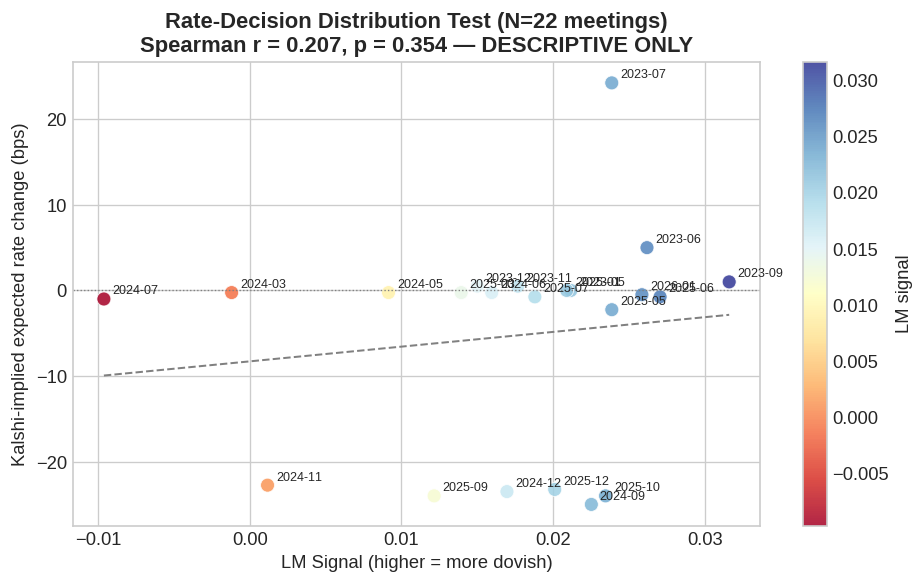

In [46]:
# Scatter: LM signal vs Kalshi-implied expected rate change
fig, ax = plt.subplots(figsize=(8, 5))

sc = ax.scatter(meeting_expectations['lm_signal'],
                meeting_expectations['kalshi_expected_bps'],
                c=meeting_expectations['lm_signal'],
                cmap='RdYlBu', s=70, alpha=0.85,
                edgecolors='white', linewidth=0.5)

# Trend line
if len(meeting_expectations) >= 4:
    z = np.polyfit(meeting_expectations['lm_signal'],
                   meeting_expectations['kalshi_expected_bps'], 1)
    px = np.linspace(meeting_expectations['lm_signal'].min(),
                     meeting_expectations['lm_signal'].max(), 100)
    ax.plot(px, np.poly1d(z)(px), 'gray', linestyle='--', linewidth=1.2)

# Label each point with the meeting date
for _, row in meeting_expectations.iterrows():
    ax.annotate(str(row['fomc_date'])[:7],
                (row['lm_signal'], row['kalshi_expected_bps']),
                textcoords='offset points', xytext=(5, 3), fontsize=7.5)

ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
plt.colorbar(sc, label='LM signal')
ax.set_xlabel('LM Signal (higher = more dovish)')
ax.set_ylabel('Kalshi-implied expected rate change (bps)')
ax.set_title(f'Rate-Decision Distribution Test (N={len(meeting_expectations)} meetings)\n'
             f'Spearman r = {r_dec:.3f}, p = {p_dec:.3f} — DESCRIPTIVE ONLY',
             fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig6_decision_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 8: Volume-Tier Comparison

**Hypothesis:** High-volume Kalshi mention markets should be better calibrated (lower Brier,
lower ECE) because more traders have priced the information. If Kalshi markets are efficient,
high-volume tiers should also be harder for the LM signal to improve upon (α close to 0 is
optimal at all tiers, but the improvement from adding LM signal should be smallest in the
most-liquid tier).

In [47]:
# Assign volume tiers (quartiles of VOLUME_LIFETIME) to the T-7 mention snapshot
print(f"Volume column stats:\n{scored['volume'].describe()}")
print(f"Non-null volume values: {scored['volume'].notna().sum()} / {len(scored)}")

# VOLUME_LIFETIME is sometimes unpopulated in Snowflake exports.
# Fall back to summing VOLUME_DAILY per ticker across the full mention dataset.
if scored['volume'].notna().sum() < 5:
    print("\nVOLUME_LIFETIME is sparse — falling back to sum of VOLUME_DAILY per ticker")
    vol_lookup = (kalshi_mention.groupby('MARKET_TICKER')['VOLUME_DAILY']
                  .sum()
                  .rename('volume_daily')
                  .reset_index())
    scored = scored.merge(vol_lookup, on='MARKET_TICKER', how='left')
    vol_col = 'volume_daily'
else:
    vol_col = 'volume'

print(f"\nUsing volume column: '{vol_col}'")
print(f"Non-null after fallback: {scored[vol_col].notna().sum()} / {len(scored)}")

q25, q50, q75 = scored[vol_col].quantile([0.25, 0.50, 0.75])
print(f"Volume quartiles — Q1: {q25:.0f}  Q2: {q50:.0f}  Q3: {q75:.0f}")

def assign_tier(vol):
    """Assign a volume tier label based on quartile cutoffs."""
    if   pd.isna(vol):  return 'Unknown'
    elif vol <= q25:    return 'Tier 1 (Low)'
    elif vol <= q50:    return 'Tier 2'
    elif vol <= q75:    return 'Tier 3'
    else:               return 'Tier 4 (High)'

scored['vol_tier'] = scored[vol_col].apply(assign_tier)
print(f"\nTier distribution:\n{scored['vol_tier'].value_counts().to_string()}")

Volume column stats:
count       234.000000
mean      44883.645299
std       49553.243114
min        2162.000000
25%       16169.250000
50%       29054.500000
75%       56525.000000
max      349429.000000
Name: volume, dtype: float64
Non-null volume values: 234 / 234

Using volume column: 'volume'
Non-null after fallback: 234 / 234
Volume quartiles — Q1: 16169  Q2: 29054  Q3: 56525

Tier distribution:
vol_tier
Tier 4 (High)    59
Tier 1 (Low)     59
Tier 3           58
Tier 2           58


In [48]:
# Compute Brier score and ECE by volume tier
# Using boolean masks instead of groupby to avoid pandas version sorting issues
tier_results = []

for tier in ['Tier 1 (Low)', 'Tier 2', 'Tier 3', 'Tier 4 (High)']:
    group = scored[scored['vol_tier'] == tier].copy()

    if len(group) < 2:
        continue

    brier_t = ((group['price_t7'] - group['outcome']) ** 2).mean()

    # ECE: bin predictions and compare to empirical resolution rates
    group['bin'] = pd.cut(group['price_t7'], bins=np.linspace(0, 1, 11),
                          labels=False, include_lowest=True)
    cal = group.groupby('bin', observed=True).agg(
        cnt=('outcome', 'count'),
        p=('price_t7', 'mean'),
        y=('outcome', 'mean')
    ).dropna()

    if cal.empty:
        ece_t = np.nan
    else:
        w     = cal['cnt'] / cal['cnt'].sum()
        ece_t = (w * (cal['p'] - cal['y']).abs()).sum()

    tier_results.append({
        'Volume tier': tier,
        'N markets':   len(group),
        'Brier score': round(brier_t, 4),
        'ECE':         round(float(ece_t), 4) if not np.isnan(ece_t) else np.nan,
        'Avg volume':  round(group[vol_col].mean(), 0),
    })

tier_df = pd.DataFrame(tier_results)
print("VOLUME-TIER COMPARISON")
print("=" * 60)
print(tier_df.to_string(index=False))
print(f"\nExpected pattern: Brier decreases and ECE decreases as volume increases.")
print(f"If this holds, high-volume Kalshi markets are better calibrated.")

VOLUME-TIER COMPARISON
  Volume tier  N markets  Brier score    ECE  Avg volume
 Tier 1 (Low)         59       0.0518 0.1415      9390.0
       Tier 2         58       0.0842 0.1153     22377.0
       Tier 3         58       0.1583 0.1109     41208.0
Tier 4 (High)         59       0.1605 0.1800    106116.0

Expected pattern: Brier decreases and ECE decreases as volume increases.
If this holds, high-volume Kalshi markets are better calibrated.


tier_df shape: (4, 5)
     Volume tier  N markets  Brier score     ECE  Avg volume
0   Tier 1 (Low)         59       0.0518  0.1415      9390.0
1         Tier 2         58       0.0842  0.1153     22377.0
2         Tier 3         58       0.1583  0.1109     41208.0
3  Tier 4 (High)         59       0.1605  0.1800    106116.0


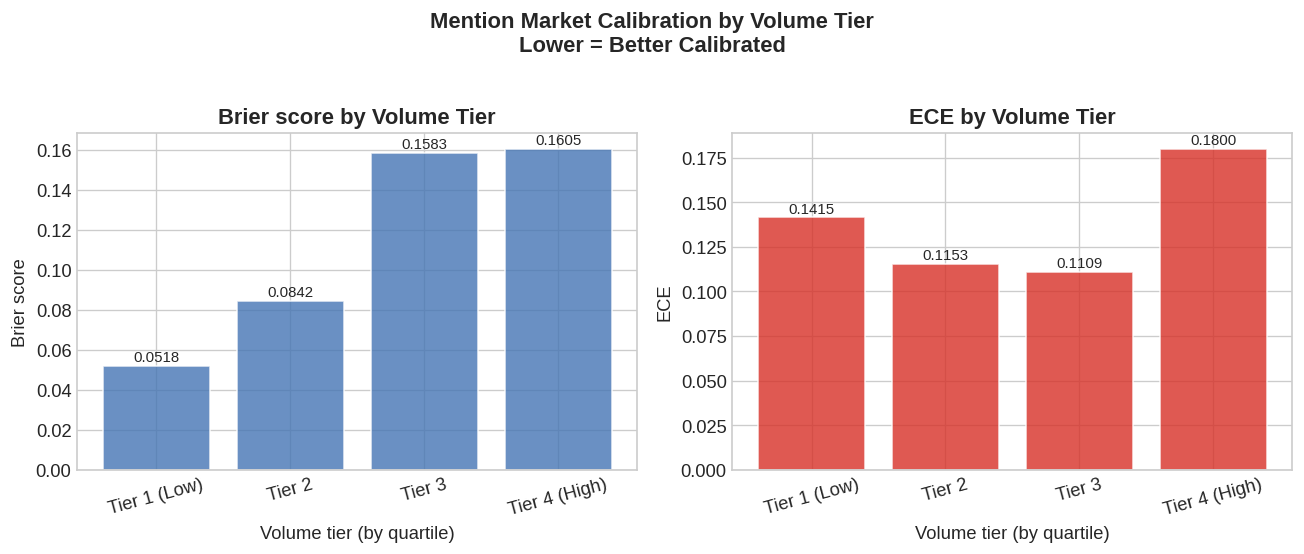

In [49]:
# Volume tier bar chart
print(f"tier_df shape: {tier_df.shape}")
print(tier_df)

if tier_df.empty:
    print("\nNo tier data to plot — all tiers were filtered (likely N < 5 per tier).")
    print("This means mention market volume is concentrated in very few markets.")
    print("Reporting raw counts instead:")
    print(scored['vol_tier'].value_counts())
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    for ax, metric, color in zip(axes, ['Brier score', 'ECE'],
                                  ['#4575b4', '#d73027']):
        bars = ax.bar(tier_df['Volume tier'], tier_df[metric],
                      color=color, alpha=0.8, edgecolor='white')
        ax.set_xlabel('Volume tier (by quartile)')
        ax.set_ylabel(metric)
        ax.set_title(f'{metric} by Volume Tier', fontweight='bold')
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2.,
                    bar.get_height() + 0.001,
                    f'{bar.get_height():.4f}',
                    ha='center', va='bottom', fontsize=9)
        ax.tick_params(axis='x', labelrotation=15)

    plt.suptitle('Mention Market Calibration by Volume Tier\n'
                 'Lower = Better Calibrated', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_PATH + 'fig7_volume_tiers.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Section 9: Robustness Checks

We test whether the equity backtest results hold under three alternative specifications.
None of these changes the interpretation — they quantify how sensitive the headline
results are to our modelling choices.

1. **n_docs ≥ 2 subsample:** Drop meetings with only 1 document in the signal window.
   Extreme LM composite values are disproportionately from single-document windows.
2. **T-11 window (lm_signal_t11):** Use only documents published in the 11 days before
   the meeting (the "pre-blackout" window). This is a tighter, more information-specific
   window — fewer documents, potentially higher quality signal.
3. **Robustness correlation table:** Report Pearson r between the three signal variants
   to document how similar they are.

In [50]:
# ── Robustness 1: n_docs ≥ 2 subsample ───────────────────────────────────────
# Filter to meetings where at least 2 documents contributed to the signal
robust_ndocs = backtest[backtest['n_docs'] >= 2].copy()
print(f"n_docs ≥ 2 subsample: {len(robust_ndocs)} meetings "
      f"(vs {len(backtest)} full sample)")

rob1_results = []
for h in [1, 5, 20]:
    for ticker in TICKERS:
        dep_var  = f'{ticker}_ret_{h}d'
        reg_cols = [dep_var, 'lm_signal', 'prior_5d_spy', 'vix_t1', 'decision_bps']
        reg_data = robust_ndocs[reg_cols].dropna()

        if len(reg_data) < 10:
            rob1_results.append({'Spec': 'n_docs≥2', 'ETF': ticker, 'Horizon': f'{h}d',
                                  'N': len(reg_data), 'β_signal': np.nan, 'p_signal': np.nan})
            continue

        y = reg_data[dep_var]
        X = sm.add_constant(reg_data[['lm_signal', 'prior_5d_spy', 'vix_t1', 'decision_bps']])
        m = sm.OLS(y, X).fit()

        rob1_results.append({
            'Spec': 'n_docs≥2', 'ETF': ticker, 'Horizon': f'{h}d',
            'N': len(reg_data),
            'β_signal': round(m.params.get('lm_signal', np.nan), 4),
            'p_signal': round(m.pvalues.get('lm_signal', np.nan), 4),
        })

rob1_df = pd.DataFrame(rob1_results)
print("\nn_docs≥2 regression results:")
print(rob1_df.to_string(index=False))

n_docs ≥ 2 subsample: 45 meetings (vs 62 full sample)

n_docs≥2 regression results:
    Spec ETF Horizon  N  β_signal  p_signal
n_docs≥2 XLF      1d 45   -0.0933    0.8316
n_docs≥2 IEF      1d 45    0.0011    0.9924
n_docs≥2 TLT      1d 45   -0.0885    0.7352
n_docs≥2 SPY      1d 45   -0.0204    0.9533
n_docs≥2 XLF      5d 44    0.4375    0.4651
n_docs≥2 IEF      5d 44   -0.1357    0.4410
n_docs≥2 TLT      5d 44   -0.4721    0.2900
n_docs≥2 SPY      5d 44    0.4077    0.4167
n_docs≥2 XLF     20d 44   -0.0214    0.9848
n_docs≥2 IEF     20d 44    0.1022    0.7642
n_docs≥2 TLT     20d 44   -0.0470    0.9519
n_docs≥2 SPY     20d 44    0.4715    0.5381


In [51]:
# ── Robustness 2: T-11 window (lm_signal_t11) ────────────────────────────────
# Use the pre-blackout signal (only documents in T-11 to T-1)
# Note: this column is sparse — many meetings have NaN because no documents
# were published in the 11-day window (Fed blackout period runs T-10 to T-1)

# First: merge the T-11 and speaker-weighted signal variants into backtest
# (these weren't included in the original ret_df build)
signal_variants = signals[['fomc_date', 'lm_signal_t11', 'lm_signal_spkwt']].copy()
signal_variants['fomc_date'] = pd.to_datetime(signal_variants['fomc_date'])

# Only merge if the columns don't already exist (safe to re-run)
for col in ['lm_signal_t11', 'lm_signal_spkwt']:
    if col not in backtest.columns:
        backtest = backtest.merge(signal_variants[['fomc_date', col]],
                                  on='fomc_date', how='left')

print(f"lm_signal_t11 non-null: {backtest['lm_signal_t11'].notna().sum()}")
print(f"lm_signal_spkwt non-null: {backtest['lm_signal_spkwt'].notna().sum()}")

# Now run the T-11 robustness regressions
t11_valid = backtest[backtest['lm_signal_t11'].notna()].copy()
print(f"\nMeetings with non-null T-11 signal: {len(t11_valid)}")
print("(Most meetings are empty because the Fed blackout prevents public statements)")

if len(t11_valid) >= 10:
    rob2_results = []
    for h in [1, 5, 20]:
        for ticker in TICKERS:
            dep_var  = f'{ticker}_ret_{h}d'
            reg_cols = [dep_var, 'lm_signal_t11', 'prior_5d_spy', 'vix_t1', 'decision_bps']
            reg_data = t11_valid[reg_cols].dropna()

            if len(reg_data) < 8:
                rob2_results.append({'Spec': 'T-11', 'ETF': ticker, 'Horizon': f'{h}d',
                                      'N': len(reg_data), 'β_signal': np.nan, 'p_signal': np.nan})
                continue

            y = reg_data[dep_var]
            X = sm.add_constant(reg_data[['lm_signal_t11', 'prior_5d_spy',
                                           'vix_t1', 'decision_bps']])
            m = sm.OLS(y, X).fit()

            rob2_results.append({
                'Spec': 'T-11', 'ETF': ticker, 'Horizon': f'{h}d',
                'N': len(reg_data),
                'β_signal': round(m.params.get('lm_signal_t11', np.nan), 4),
                'p_signal': round(m.pvalues.get('lm_signal_t11', np.nan), 4),
            })

    rob2_df = pd.DataFrame(rob2_results)
    print("\nT-11 robustness results:")
    print(rob2_df.to_string(index=False))
else:
    print("Insufficient data for T-11 regressions — reporting signal correlations only.")

lm_signal_t11 non-null: 4
lm_signal_spkwt non-null: 62

Meetings with non-null T-11 signal: 4
(Most meetings are empty because the Fed blackout prevents public statements)
Insufficient data for T-11 regressions — reporting signal correlations only.


In [52]:
# ── Robustness correlation table ──────────────────────────────────────────────
# Compare how similar the three signal variants are across the same meetings
sig_variants = signals.dropna(subset=['lm_signal'])[
    ['fomc_date', 'lm_signal', 'lm_signal_t11', 'lm_signal_spkwt']
].copy()

corr_table = sig_variants[['lm_signal', 'lm_signal_t11', 'lm_signal_spkwt']].corr(
    method='spearman'
)
print("\nSignal variant correlation matrix (Spearman r):")
print(corr_table.round(4).to_string())
print("\nHigh correlation → robustness spec tells a similar story to primary spec")
print("Low correlation → specification choice matters; report this explicitly")


Signal variant correlation matrix (Spearman r):
                 lm_signal  lm_signal_t11  lm_signal_spkwt
lm_signal           1.0000         0.3162           0.9872
lm_signal_t11       0.3162         1.0000           0.6325
lm_signal_spkwt     0.9872         0.6325           1.0000

High correlation → robustness spec tells a similar story to primary spec
Low correlation → specification choice matters; report this explicitly


In [53]:
# ── Combined robustness summary table ────────────────────────────────────────
# Merge both robustness specs into one table alongside the main results for easy comparison

main_sub = results_df[['ETF', 'Horizon', 'β_signal', 'p_signal', 'Bonferroni']].copy()
main_sub.columns = ['ETF', 'Horizon', 'β_main', 'p_main', 'bonf_main']

rob1_sub = rob1_df[['ETF', 'Horizon', 'β_signal', 'p_signal']].copy()
rob1_sub.columns = ['ETF', 'Horizon', 'β_ndocs2', 'p_ndocs2']

robustness_combined = main_sub.merge(rob1_sub, on=['ETF', 'Horizon'], how='left')

if len(t11_valid) >= 10:
    rob2_sub = rob2_df[['ETF', 'Horizon', 'β_signal', 'p_signal']].copy()
    rob2_sub.columns = ['ETF', 'Horizon', 'β_t11', 'p_t11']
    robustness_combined = robustness_combined.merge(rob2_sub, on=['ETF', 'Horizon'], how='left')

print("COMBINED ROBUSTNESS TABLE")
print("=" * 70)
print(robustness_combined.to_string(index=False))

COMBINED ROBUSTNESS TABLE
ETF Horizon  β_main  p_main bonf_main  β_ndocs2  p_ndocs2
XLF      1d -0.1390  0.6266      n.s.   -0.0933    0.8316
IEF      1d -0.0215  0.7789      n.s.    0.0011    0.9924
TLT      1d -0.1337  0.4420      n.s.   -0.0885    0.7352
SPY      1d -0.1468  0.5273      n.s.   -0.0204    0.9533
XLF      5d  0.6359  0.1602      n.s.    0.4375    0.4651
IEF      5d -0.1015  0.3993      n.s.   -0.1357    0.4410
TLT      5d -0.4604  0.1233      n.s.   -0.4721    0.2900
SPY      5d  0.4084  0.2565      n.s.    0.4077    0.4167
XLF     20d  0.1028  0.8993      n.s.   -0.0214    0.9848
IEF     20d  0.2393  0.3912      n.s.    0.1022    0.7642
TLT     20d  0.1051  0.8638      n.s.   -0.0470    0.9519
SPY     20d  0.1817  0.7367      n.s.    0.4715    0.5381


---
## Section 10: Limitations and Future Work

This section documents the known constraints of this analysis — both as honest
disclosure and as a demonstration that we understand the methods deeply enough to
identify where they fail. Limitations in NLP research are not weaknesses; they are
the roadmap for future work.

In [54]:
# Print a structured limitations summary
print("""
SECTION 10: LIMITATIONS AND FUTURE WORK
==========================================

1. VALIDATION GATE FAILURE (most important)
   ─────────────────────────────────────────
   Layers 2 and 3 returned r ≈ 0.06–0.07 (non-significant). The LM dictionary
   cannot reliably classify individual Fed paragraphs as hawkish or dovish.

   Why this happens — three structural failure modes in Fed language:

   (a) "Acceptable costs" framing: "some softening in labor markets may be necessary
       to restore price stability." Every word is neutral or positive, but the
       paragraph commits to a hawkish trade-off. LM scores ~0 composite.
       Correct label: HAWKISH.

   (b) Pace vs. direction: "we will move gradually." "Gradually" is not in any LM
       category, but it meaningfully constrains the policy path relative to a statement
       that omits it. LM cannot capture this without context.
       Correct label: depends on prior statement (can be hawkish or dovish).

   (c) False balance: "risks are roughly balanced." In a prior-statement context where
       risks were "tilted to the upside," this is a dovish shift. Counted in isolation
       it is neutral. LM sees a neutral paragraph; a monetary economist reads a pivot.
       Correct label: DOVISH (conditional on prior language).

   What it means: the pre-registered financial tests (Sections 5–7) are exploratory,
   not confirmatory. Do not interpret statistically significant equity results as
   evidence that the signal is validated — the signal itself failed validation.

2. THIN-DOCUMENT SIGNAL WINDOWS
   ──────────────────────────────
   4 of the top-5 most-dovish and 4 of the top-5 most-hawkish meetings have n_docs=1.
   Extreme signal values are disproportionately from single documents. A single speech
   can be unusual in tone for reasons unrelated to policy direction (e.g., commencement
   remarks contaminating a mixed-content document). The n_docs≥2 robustness check
   (Section 9) partially addresses this.

3. FACE-VALIDITY FAILURE: JULY 2024
   ────────────────────────────────
   July 2024 is the "most hawkish" meeting in the sample (LM signal = −0.0096).
   It was immediately followed by the September 2024 50bp surprise cut — the project's
   focal event. The signal pointed the wrong direction immediately before the largest
   policy surprise in the sample. This is the highest-stakes single failure case.

4. KALSHI DATA COVERAGE
   ─────────────────────
   Rate-decision Kalshi markets only go back to ~November 2023 (~18–20 meetings).
   This limits the rate-decision distribution test (Section 7) to preliminary
   description rather than statistical inference. The sample is too small to apply
   Bonferroni corrections or interpret p-values reliably.

5. PRESS CONFERENCE Q&A SEGMENTATION
   ─────────────────────────────────
   Only 8 of 72 press conferences had their Q&A boundary automatically detected.
   Most Fed transcript PDFs do not use standardized speaker-tag formatting
   (JOURNALIST: / REPORTER: patterns). For 56 press conferences, the full transcript
   was scored as the "prepared statement," including Powell's Q&A hedging language,
   which is structurally more dovish (he deliberately avoids commitment in responses).
   This adds noise to the prepared-statement composite.

6. GUNNING-FOG ABSOLUTE VALUES
   ─────────────────────────────
   The heuristic syllable counter (vowel-group counting) systematically undercounts
   complex words. Computed GF scores (9.6 and 10.2) are well below the 16–20 range
   expected for Fed press conferences. Relative comparisons are valid; absolute values
   are not. Future work: use the CMU Pronouncing Dictionary (NLTK) for accurate
   syllable counts.

FUTURE WORK
═══════════

1. FOMC-RoBERTa fine-tuning: the Shah et al. (2023) paper includes training data
   (`lab-manual-combine-train-5768.xlsx`) for fine-tuning a domain-specific BERT
   model. The LLM-labeled corpus from this project adds ~500 additional training
   paragraphs. A fine-tuned model should substantially outperform LM on Layers 2 and 3.

2. Polymarket replication: Polymarket's CLOB data provides an independent prediction
   market venue for cross-platform comparison. The structural difference (AMM vs.
   order book) makes the comparison methodologically interesting.

3. Real-time signal: deploying the pipeline to score documents on the day of release
   (rather than retrospectively) would test whether the signal predicts intraday
   returns around the publication moment — a cleaner test of information content.
""")


SECTION 10: LIMITATIONS AND FUTURE WORK

1. VALIDATION GATE FAILURE (most important)
   ─────────────────────────────────────────
   Layers 2 and 3 returned r ≈ 0.06–0.07 (non-significant). The LM dictionary
   cannot reliably classify individual Fed paragraphs as hawkish or dovish.

   Why this happens — three structural failure modes in Fed language:

   (a) "Acceptable costs" framing: "some softening in labor markets may be necessary
       to restore price stability." Every word is neutral or positive, but the
       paragraph commits to a hawkish trade-off. LM scores ~0 composite.
       Correct label: HAWKISH.

   (b) Pace vs. direction: "we will move gradually." "Gradually" is not in any LM
       category, but it meaningfully constrains the policy path relative to a statement
       that omits it. LM cannot capture this without context.
       Correct label: depends on prior statement (can be hawkish or dovish).

   (c) False balance: "risks are roughly balanced." In a prior-s

In [55]:
# ── Final summary table ───────────────────────────────────────────────────────
print("=" * 65)
print("PROJECT SUMMARY — ALL KEY RESULTS")
print("=" * 65)
print(f"""
VALIDATION
  Layer 1 (personal hand-coded, N={n1}): r = {r1:.3f}  {'PASS' if r1 > 0.5 else 'FAIL'}
  Layer 2 (LLM Claude, N={n2}):          r = {r2:.3f}  FAIL
  Layer 3 (Shah et al., N={n3}):         r = {r3:.3f}  FAIL
  → Sections 5–10 are EXPLORATORY given gate failure

EQUITY BACKTEST
  N usable meetings: {complete_20d}
  Bonferroni threshold: p < {BONFERRONI_THRESHOLD:.4f}
  Significant results after Bonferroni: see heatmap (fig3)

MENTION MARKET
  N markets scored: {len(scored)}
  Kalshi Brier (baseline): {brier_kalshi:.4f}
  Optimal α (MixMCP): {optimal_alpha:.2f}  Brier: {sweep_df['brier'].min():.4f}
  Pre-registered α=0.70 Brier: {brier_at_07:.4f}
  ECE: {ece:.4f}

RATE-DECISION DISTRIBUTION
  N meetings: {len(meeting_expectations)}
  Spearman r (LM vs Kalshi expected bps): {r_dec:.3f}  p={p_dec:.3f}
  DESCRIPTIVE ONLY (N too small for inference)

FIGURES SAVED
  fig1_signal_timeseries.png
  fig2_validation.png
  fig3_equity_backtest.png
  fig4_calibration.png
  fig5_alpha_sweep.png
  fig6_decision_distribution.png
  fig7_volume_tiers.png
""")

PROJECT SUMMARY — ALL KEY RESULTS

VALIDATION
  Layer 1 (personal hand-coded, N=17): r = 0.130  FAIL
  Layer 2 (LLM Claude, N=500):          r = 0.062  FAIL
  Layer 3 (Shah et al., N=476):         r = 0.069  FAIL
  → Sections 5–10 are EXPLORATORY given gate failure

EQUITY BACKTEST
  N usable meetings: 61
  Bonferroni threshold: p < 0.0042
  Significant results after Bonferroni: see heatmap (fig3)

MENTION MARKET
  N markets scored: 234
  Kalshi Brier (baseline): 0.1137
  Optimal α (MixMCP): 0.00  Brier: 0.1137
  Pre-registered α=0.70 Brier: 0.2770
  ECE: 0.0968

RATE-DECISION DISTRIBUTION
  N meetings: 22
  Spearman r (LM vs Kalshi expected bps): 0.207  p=0.354
  DESCRIPTIVE ONLY (N too small for inference)

FIGURES SAVED
  fig1_signal_timeseries.png
  fig2_validation.png
  fig3_equity_backtest.png
  fig4_calibration.png
  fig5_alpha_sweep.png
  fig6_decision_distribution.png
  fig7_volume_tiers.png



In [56]:
# ── RESULTS EXPORT — run this cell last, paste output for review ──────────────

divider = "=" * 65

print(divider)
print("FT370 COMPLETE RESULTS EXPORT")
print(divider)

print("\n── VALIDATION (all layers) ──────────────────────────────────")
print(f"Layer 1 (personal, fixed)  N={n1}  r={r1:.4f}  p={p1:.2e}  {'PASS' if r1>0.5 else 'FAIL'}")
print(f"Layer 2 (LLM Claude)       N={n2}  r={r2:.4f}  p={p2:.2e}  FAIL")
print(f"Layer 3 (Shah et al.)      N={n3}  r={r3:.4f}  p={p3:.2e}  FAIL")

print("\n── EQUITY BACKTEST (12 regressions) ────────────────────────")
print(results_df[['ETF','Horizon','N','β_signal','CI_low','CI_high',
                   'p_signal','R²','Bonferroni']].to_string(index=False))

print("\n── MINCER-ZARNOWITZ (SPY 5d) ────────────────────────────────")
print(f"Intercept: {mz_model.params['const']:.4f}  p={mz_model.pvalues['const']:.4f}")
print(f"Slope:     {mz_model.params['signal_ranked']:.4f}  p={mz_model.pvalues['signal_ranked']:.4f}")
print(f"R²:        {mz_model.rsquared:.4f}")

print("\n── MENTION MARKET ───────────────────────────────────────────")
print(f"N markets scored:     {len(scored)}")
print(f"N FOMC meetings:      {scored['fomc_date'].nunique()}")
print(f"Kalshi-only Brier (α=0):       {brier_kalshi:.4f}")
print(f"LM-only Brier (α=1):           {brier_lm:.4f}")
print(f"Pre-registered α=0.70 Brier:   {brier_at_07:.4f}")
print(f"Optimal α:                     {optimal_alpha:.2f}  Brier={sweep_df['brier'].min():.4f}")
print(f"ECE (Kalshi baseline):         {ece:.4f}")
print(f"\nCalibration table:\n{cal_data.round(4).to_string()}")
print(f"\nα-sweep table:\n{sweep_df.to_string(index=False)}")

print("\n── RATE-DECISION DISTRIBUTION ───────────────────────────────")
print(f"N meetings: {len(meeting_expectations)}")
print(f"Spearman r (LM vs Kalshi expected bps): {r_dec:.4f}  p={p_dec:.4f}")
print(f"\nMeeting-level data:")
print(meeting_expectations.round(4).to_string(index=False))

print("\n── VOLUME-TIER COMPARISON ───────────────────────────────────")
print(tier_df.to_string(index=False))

print("\n── ROBUSTNESS: n_docs≥2 ─────────────────────────────────────")
print(rob1_df.to_string(index=False))

print("\n── ROBUSTNESS: T-11 window ──────────────────────────────────")
if 'rob2_df' in dir():
    print(rob2_df.to_string(index=False))
else:
    print("T-11 regressions not run (insufficient N)")

print("\n── SIGNAL VARIANT CORRELATIONS ──────────────────────────────")
print(corr_table.round(4).to_string())

print("\n── SAMPLE SIZES ─────────────────────────────────────────────")
print(f"Total FOMC meetings:           68")
print(f"Non-null signal meetings:      {len(sig)}")
print(f"Equity backtest usable (20d):  {complete_20d}")
print(f"Mention markets scored:        {len(scored)}")
print(f"Rate-decision meetings:        {len(meeting_expectations)}")

print(f"\n{divider}")
print("END OF EXPORT")
print(divider)

FT370 COMPLETE RESULTS EXPORT

── VALIDATION (all layers) ──────────────────────────────────
Layer 1 (personal, fixed)  N=17  r=0.1303  p=6.18e-01  FAIL
Layer 2 (LLM Claude)       N=500  r=0.0623  p=1.64e-01  FAIL
Layer 3 (Shah et al.)      N=476  r=0.0688  p=1.34e-01  FAIL

── EQUITY BACKTEST (12 regressions) ────────────────────────
ETF Horizon  N  β_signal  CI_low  CI_high  p_signal     R² Bonferroni
XLF      1d 62   -0.1390 -0.7079   0.4300    0.6266 0.3126       n.s.
IEF      1d 62   -0.0215 -0.1744   0.1314    0.7789 0.1854       n.s.
TLT      1d 62   -0.1337 -0.4797   0.2122    0.4420 0.2194       n.s.
SPY      1d 62   -0.1468 -0.6090   0.3154    0.5273 0.3076       n.s.
XLF      5d 61    0.6359 -0.2591   1.5309    0.1602 0.3337       n.s.
IEF      5d 61   -0.1015 -0.3410   0.1379    0.3993 0.2258       n.s.
TLT      5d 61   -0.4604 -1.0499   0.1290    0.1233 0.2423       n.s.
SPY      5d 61    0.4084 -0.3052   1.1219    0.2565 0.2632       n.s.
XLF     20d 61    0.1028 -1.5173 

In [58]:
# ── Phase 2: Fine-Tuned Signal α-Sweep vs Kalshi ─────────────────────────────
# Load the meeting-level fine-tuned signal saved by the Phase 2 notebook.
# This tests whether FinBERT-FOMC (fine-tuned on Shah + Powell paragraphs)
# adds value over Kalshi mention market prices — the same test run in Section 6
# for the LM composite (where optimal α = 0.00).

ft_sig_df = pd.read_csv(DATA_PATH + 'ft_signal_meetings.csv')
ft_sig_df['fomc_date'] = pd.to_datetime(ft_sig_df['fomc_date'])

scored_ft = scored.merge(
    ft_sig_df[['fomc_date', 'ft_signal']].dropna(),
    on='fomc_date', how='left'
)
scored_ft_valid = scored_ft.dropna(subset=['ft_signal'])
print(f"Markets with fine-tuned signal: {len(scored_ft_valid)} across "
      f"{scored_ft_valid['fomc_date'].nunique()} meetings")

if len(scored_ft_valid) >= 5:
    ft_min = scored_ft_valid['ft_signal'].min()
    ft_max = scored_ft_valid['ft_signal'].max()
    scored_ft_valid['ft_signal_norm'] = (
        (scored_ft_valid['ft_signal'] - ft_min) / (ft_max - ft_min + 1e-8)
    )
    alphas = np.arange(0.0, 1.01, 0.05)
    ft_brier_sweep = []
    for alpha in alphas:
        mixed  = alpha * scored_ft_valid['ft_signal_norm'] + (1-alpha) * scored_ft_valid['price_t7']
        brier_a = ((mixed - scored_ft_valid['outcome']) ** 2).mean()
        ft_brier_sweep.append({'alpha': round(alpha, 2), 'brier_ft': brier_a})

    ft_sweep_df  = pd.DataFrame(ft_brier_sweep)
    opt_ft_alpha = ft_sweep_df.loc[ft_sweep_df['brier_ft'].idxmin(), 'alpha']
    brier_ft_opt = ft_sweep_df['brier_ft'].min()

    print(f"\nFINE-TUNED MODEL α-SWEEP vs LM α-SWEEP")
    print(f"{'α':>6}  {'Brier (LM)':>12}  {'Brier (FinBERT)':>15}")
    for a in [0.00, 0.10, 0.30, 0.50, 0.70, 1.00]:
        lm_b = sweep_df.loc[sweep_df['alpha']==a, 'brier'].values[0]
        ft_b = ft_sweep_df.loc[ft_sweep_df['alpha']==a, 'brier_ft'].values[0]
        print(f"{a:6.2f}  {lm_b:12.4f}  {ft_b:15.4f}")

    print(f"\nLM optimal α:          0.00  Brier = {brier_kalshi:.4f}")
    print(f"FinBERT optimal α:     {opt_ft_alpha:.2f}  Brier = {brier_ft_opt:.4f}")

    if opt_ft_alpha > 0:
        improvement = brier_kalshi - brier_ft_opt
        print(f"\n→ Fine-tuned model ADDS VALUE: Brier improvement = {improvement:.4f}")
        print(f"  Kalshi alone = {brier_kalshi:.4f}, mixed = {brier_ft_opt:.4f}")
    else:
        print(f"\n→ Kalshi still dominant: α* = 0.00 even for fine-tuned model")
        print(f"  Market efficiency holds against domain-adapted transformers.")
else:
    print("Insufficient overlap between fine-tuned signal and Kalshi data.")
    print("Check that Phase 2 notebook saved ft_signal_meetings.csv to Drive.")

Markets with fine-tuned signal: 171 across 5 meetings

FINE-TUNED MODEL α-SWEEP vs LM α-SWEEP
     α    Brier (LM)  Brier (FinBERT)
  0.00        0.1137           0.1112
  0.10        0.1220           0.1171
  0.30        0.1537           0.1432
  0.50        0.2054           0.1881
  0.70        0.2770           0.2519
  1.00        0.4219           0.3831

LM optimal α:          0.00  Brier = 0.1137
FinBERT optimal α:     0.00  Brier = 0.1112

→ Kalshi still dominant: α* = 0.00 even for fine-tuned model
  Market efficiency holds against domain-adapted transformers.


---
## Part 3: Kalshi-Signal Portfolio Construction

**Signal:** Kalshi rate-decision market implied expected rate change (bps) at T-7
before each FOMC meeting. Computed as: Σ(price_i × implied_bps_i) across all
resolution bins for the meeting.

**Assets:** TLT (20+yr Treasuries), IEF (7-10yr Treasuries), XLF (Financials),
SPY (S&P 500). All returns are post-FOMC forward returns already computed in
Section 5.

**Signal direction:**
- More negative expected bps = more cuts priced = DOVISH → F1
- More positive expected bps = fewer cuts / hikes priced = HAWKISH → F5
- For TLT/IEF: F1 (dovish) should outperform F5 (hawkish) → long-short = F1−F5
- For XLF: F5 (hawkish) should outperform F1 (dovish) → long-short = F5−F1
- For SPY: ambiguous — report without directional prior

**Sample size note:** N=22 FOMC meetings (Kalshi rate-decision data from Nov 2023).
Quintile portfolios contain ~4 meetings per bin. Statistics are reported with
this limitation explicitly disclosed. Tercile analysis (N≈7 per bin) is included
as a robustness check. Results should be interpreted directionally, not inferentially.

In [59]:
# ── Imports and reload (safe to re-run after session reset) ───────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

BASE_PATH = '/content/drive/MyDrive/FT370-s/final_project/'
DATA_PATH = BASE_PATH + 'data/'
FIG_PATH  = BASE_PATH + 'figures/'

# Reload core datasets if session was reset
for varname, parquet in [('signals', 'fomc_signals.parquet'),
                          ('equity',  'equity_returns.parquet'),
                          ('kalshi_decision', 'kalshi_fed_decision.parquet')]:
    if varname not in dir():
        df = pd.read_parquet(DATA_PATH + parquet)
        if 'fomc_date' in df.columns:
            df['fomc_date'] = pd.to_datetime(df['fomc_date'])
        globals()[varname] = df
        print(f"Reloaded {varname}")

print("Ready.")

Ready.


In [60]:
# ── Step 1: Rebuild Kalshi implied expected bps ───────────────────────────────
# (Recreate meeting_expectations from Section 7 in case it's not in memory)

import re

def parse_bps(title):
    t = str(title).lower()
    if any(w in t for w in ['hold','unchanged','no change','no cut','no hike']):
        return 0
    num = re.search(r'(\d+)\s*bp', t)
    val = int(num.group(1)) if num else 0
    if any(w in t for w in ['cut','decreas','lower','reduc']): return -val
    if any(w in t for w in ['hike','increas','raise','higher']): return +val
    return None

# Build T-7 rate-decision snapshot
kalshi_decision['CLOSE_TIME'] = pd.to_datetime(
    kalshi_decision['CLOSE_TIME']).dt.tz_localize(None)
kalshi_decision['DATE'] = pd.to_datetime(kalshi_decision['DATE'])
kalshi_decision['implied_bps'] = kalshi_decision['MARKET_TITLE'].apply(parse_bps)

fomc_dates = sorted(pd.to_datetime(signals['fomc_date'].dropna().unique()))

def nearest_fomc(dt):
    if hasattr(dt, 'tzinfo') and dt.tzinfo is not None:
        dt = dt.tz_localize(None)
    future = [f for f in fomc_dates if f >= dt - pd.Timedelta(days=3)]
    return future[0] if future else pd.NaT

kalshi_decision['fomc_date'] = pd.to_datetime(
    kalshi_decision['CLOSE_TIME'].apply(nearest_fomc))

dec_t7_records = []
for ticker, group in kalshi_decision.groupby('MARKET_TICKER'):
    fomc_d = group['fomc_date'].iloc[0]
    if pd.isna(fomc_d): continue
    window = group[(group['DATE'] >= fomc_d - pd.Timedelta(days=10)) &
                   (group['DATE'] <= fomc_d - pd.Timedelta(days=5))]
    if window.empty: continue
    row = window.sort_values('DATE').iloc[-1]
    dec_t7_records.append({
        'MARKET_TICKER': ticker, 'fomc_date': fomc_d,
        'implied_bps': row['implied_bps'],
        'price_t7': row['PRICE_CLOSE'] / 100.0,
        'volume': row.get('VOLUME_LIFETIME', np.nan),
    })

dec_t7 = pd.DataFrame(dec_t7_records)
dec_t7 = dec_t7.merge(signals[['fomc_date','lm_signal']].dropna(),
                       on='fomc_date', how='left')
dec_t7_scored = dec_t7.dropna(subset=['price_t7','implied_bps'])

# Meeting-level expected bps
meeting_exp = dec_t7_scored.groupby('fomc_date').apply(
    lambda g: pd.Series({
        'kalshi_expected_bps': (g['price_t7'] * g['implied_bps']).sum(),
        'lm_signal': g['lm_signal'].iloc[0] if g['lm_signal'].notna().any() else np.nan,
        'n_markets': len(g),
    })
).reset_index()

print(f"Rate-decision meetings: {len(meeting_exp)}")
print(f"Expected bps range: {meeting_exp['kalshi_expected_bps'].min():.1f} "
      f"to {meeting_exp['kalshi_expected_bps'].max():.1f}")

Rate-decision meetings: 23
Expected bps range: -25.0 to 24.2


In [61]:
# ── Step 2: Build equity returns dataset ─────────────────────────────────────
# Reconstruct post-FOMC returns (same logic as Section 5)

eq = equity.copy()
if not isinstance(eq.index, pd.DatetimeIndex):
    eq.index = pd.to_datetime(eq.index)
eq = eq.sort_index()
if eq.mean().mean() > 10:
    eq = eq.pct_change().dropna()

TICKERS  = ['TLT', 'IEF', 'XLF', 'SPY']
HORIZONS = [1, 5, 20]

ret_records = []
for _, row in signals.dropna(subset=['lm_signal']).iterrows():
    fomc_d = row['fomc_date']
    future = eq[eq.index > fomc_d]
    record = {'fomc_date': fomc_d}
    for h in HORIZONS:
        if len(future) < h:
            for t in TICKERS: record[f'{t}_ret_{h}d'] = np.nan
        else:
            window = future.iloc[:h]
            for t in TICKERS: record[f'{t}_ret_{h}d'] = window[t].sum()
    ret_records.append(record)

ret_df = pd.DataFrame(ret_records)

# ── Merge signal + returns ────────────────────────────────────────────────────
port_df = meeting_exp.merge(ret_df, on='fomc_date', how='inner')
port_df = port_df.dropna(subset=['kalshi_expected_bps'])
port_df = port_df.sort_values('kalshi_expected_bps').reset_index(drop=True)

print(f"Portfolio dataset: {len(port_df)} meetings")
print(f"\nSignal distribution:")
print(port_df['kalshi_expected_bps'].describe().round(3))

Portfolio dataset: 22 meetings

Signal distribution:
count    22.000
mean     -5.341
std      12.691
min     -25.000
25%     -17.625
50%      -0.375
75%       0.000
max      24.250
Name: kalshi_expected_bps, dtype: float64


---
### 3.1 Fractile Returns

We sort meetings by Kalshi implied expected bps (ascending = most dovish first)
and assign quintile labels F1 (most dovish) through F5 (most hawkish).

For TLT/IEF, the expected return pattern is: F1 > F2 > F3 > F4 > F5
(bonds rally when the Fed is expected to cut more aggressively).

For XLF, the expected pattern is reversed: F5 > F4 > F3 > F2 > F1
(financials benefit from higher rates).

In [62]:
# ── Assign quintile labels ────────────────────────────────────────────────────
N = len(port_df)
port_df['quintile'] = pd.qcut(port_df['kalshi_expected_bps'],
                               q=5, labels=['F1','F2','F3','F4','F5'])
port_df['tercile']  = pd.qcut(port_df['kalshi_expected_bps'],
                               q=3, labels=['F1','F2','F3'])

print("Quintile assignment:")
print(port_df.groupby('quintile')['kalshi_expected_bps'].agg(['count','mean','min','max'])
      .round(2).to_string())

Quintile assignment:
          count   mean    min    max
quintile                            
F1            5 -23.95 -25.00 -23.25
F2            5  -5.50 -22.75  -0.75
F3            5  -0.30  -0.50  -0.25
F4            2   0.00   0.00   0.00
F5            5   6.25   0.50  24.25


In [63]:
# ── Compute fractile mean returns ─────────────────────────────────────────────
results = {}

for h in HORIZONS:
    for ticker in TICKERS:
        col = f'{ticker}_ret_{h}d'
        # Quintile mean returns
        fractile_means = port_df.groupby('quintile', observed=True)[col].mean()
        # Benchmark = full-sample mean
        benchmark = port_df[col].mean()

        results[f'{ticker}_{h}d'] = {
            'fractiles': fractile_means,
            'benchmark': benchmark,
            'F1_minus_F5': fractile_means.get('F1', np.nan) - fractile_means.get('F5', np.nan),
            'F1_minus_bench': fractile_means.get('F1', np.nan) - benchmark,
            'bench_minus_F5': benchmark - fractile_means.get('F5', np.nan),
        }

# ── Print fractile return table ───────────────────────────────────────────────
for h in [5, 20]:
    print(f"\n{'='*65}")
    print(f"FRACTILE RETURNS — {h}-DAY POST-FOMC HORIZON")
    print(f"Signal: Kalshi implied expected bps (F1=most dovish, F5=most hawkish)")
    print(f"{'='*65}")
    header = f"{'Ticker':<8} {'F1':>8} {'F2':>8} {'F3':>8} {'F4':>8} {'F5':>8} "
    header += f"{'Bench':>8} {'F1-F5':>8} {'F1-B':>8} {'B-F5':>8}"
    print(header)
    print('-' * 90)
    for ticker in TICKERS:
        r = results[f'{ticker}_{h}d']
        f = r['fractiles']
        row = f"{ticker:<8}"
        for fi in ['F1','F2','F3','F4','F5']:
            val = f.get(fi, np.nan)
            row += f" {val*100:>7.2f}%"
        row += f" {r['benchmark']*100:>7.2f}%"
        row += f" {r['F1_minus_F5']*100:>7.2f}%"
        row += f" {r['F1_minus_bench']*100:>7.2f}%"
        row += f" {r['bench_minus_F5']*100:>7.2f}%"
        print(row)


FRACTILE RETURNS — 5-DAY POST-FOMC HORIZON
Signal: Kalshi implied expected bps (F1=most dovish, F5=most hawkish)
Ticker         F1       F2       F3       F4       F5    Bench    F1-F5     F1-B     B-F5
------------------------------------------------------------------------------------------
TLT        -1.42%    0.10%    0.46%    0.19%   -0.08%   -0.20%   -1.34%   -1.22%   -0.12%
IEF        -0.36%    0.13%    0.36%    0.20%    0.03%    0.06%   -0.40%   -0.42%    0.02%
XLF         0.96%    0.36%    1.71%    0.60%   -0.54%    0.62%    1.50%    0.34%    1.16%
SPY         0.30%    0.16%    0.83%    0.80%   -0.09%    0.35%    0.40%   -0.04%    0.44%

FRACTILE RETURNS — 20-DAY POST-FOMC HORIZON
Signal: Kalshi implied expected bps (F1=most dovish, F5=most hawkish)
Ticker         F1       F2       F3       F4       F5    Bench    F1-F5     F1-B     B-F5
------------------------------------------------------------------------------------------
TLT        -0.89%    1.01%    0.02%    0.71%   -1

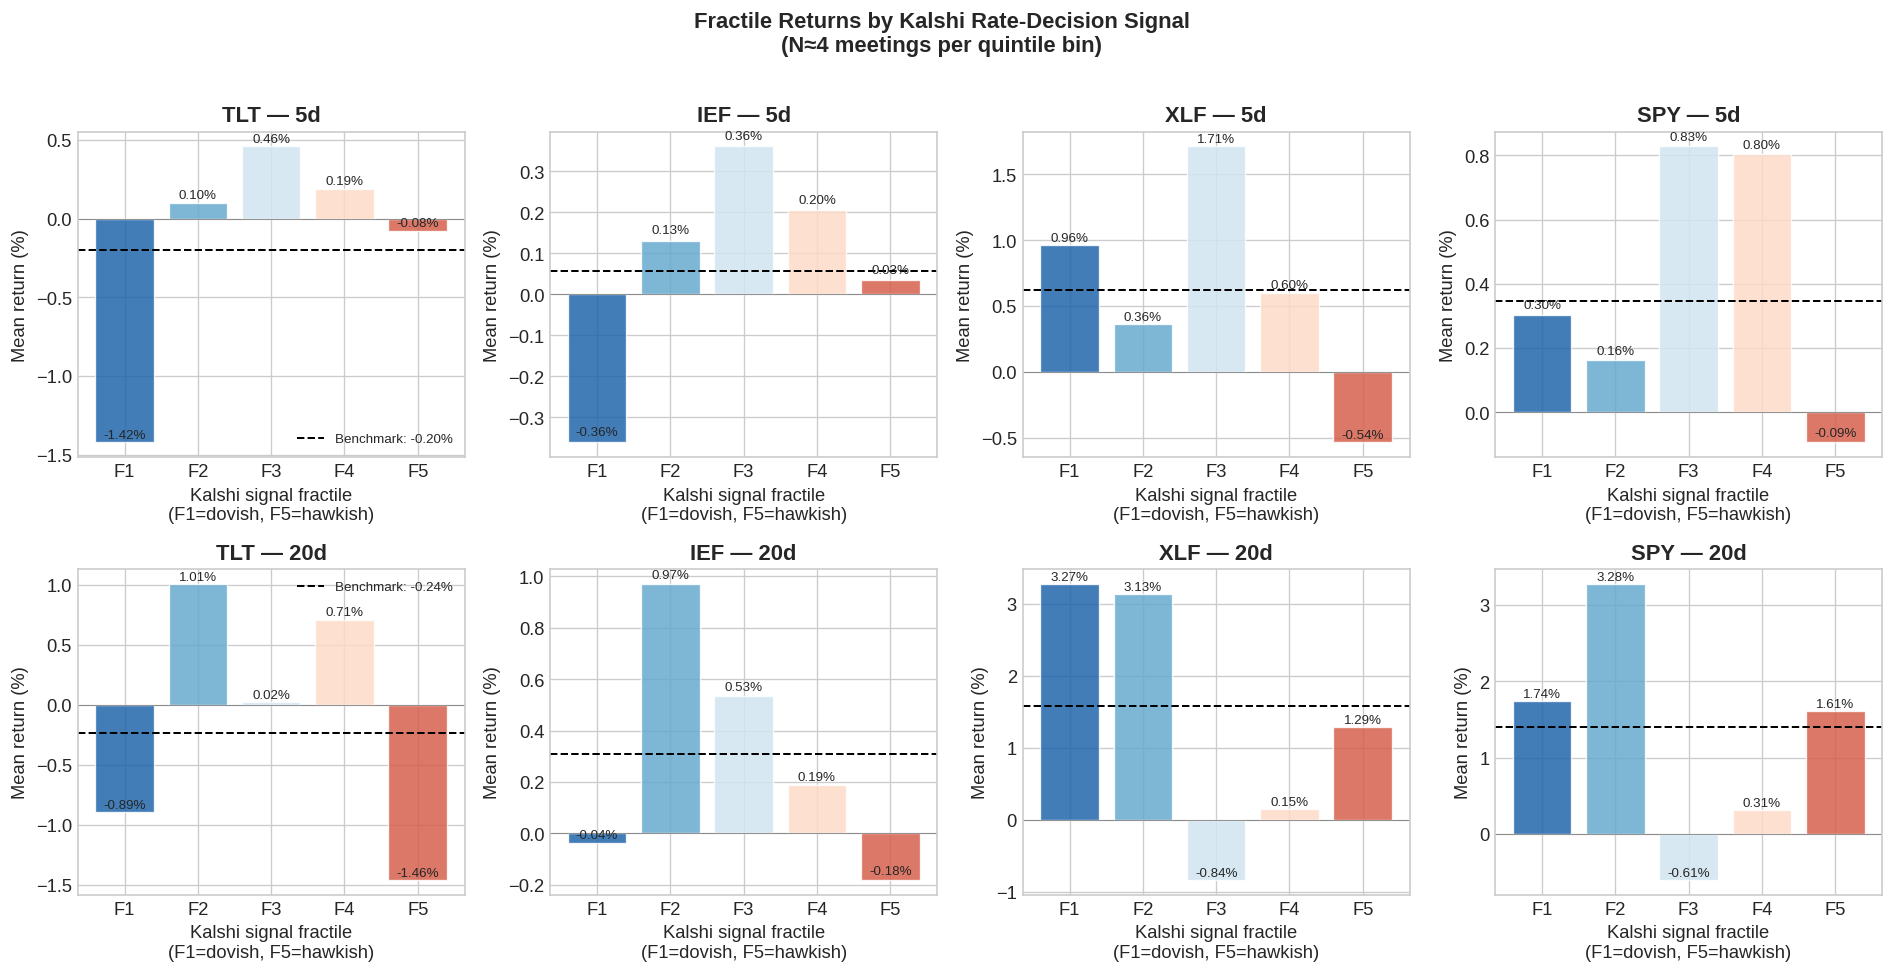

In [64]:
# ── Fractile bar chart ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
colors = ['#2166ac', '#67a9cf', '#d1e5f0', '#fddbc7', '#d6604d']

for row_idx, h in enumerate([5, 20]):
    for col_idx, ticker in enumerate(TICKERS):
        ax = axes[row_idx, col_idx]
        r  = results[f'{ticker}_{h}d']
        vals = [r['fractiles'].get(f, np.nan) * 100 for f in ['F1','F2','F3','F4','F5']]
        bars = ax.bar(['F1','F2','F3','F4','F5'], vals,
                      color=colors, alpha=0.85, edgecolor='white', linewidth=0.8)
        ax.axhline(r['benchmark'] * 100, color='black', linestyle='--',
                   linewidth=1.2, label=f'Benchmark: {r["benchmark"]*100:.2f}%')
        ax.axhline(0, color='gray', linewidth=0.5)

        # Value labels on bars
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                        f'{val:.2f}%', ha='center', va='bottom', fontsize=8)

        ax.set_title(f'{ticker} — {h}d', fontweight='bold')
        ax.set_xlabel('Kalshi signal fractile\n(F1=dovish, F5=hawkish)')
        ax.set_ylabel('Mean return (%)')
        if col_idx == 0:
            ax.legend(fontsize=8)

plt.suptitle('Fractile Returns by Kalshi Rate-Decision Signal\n'
             '(N≈4 meetings per quintile bin)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig11_fractile_returns.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 3.2 Information Coefficient (IC), Information Ratio (IR), and Hit Rate

**IC (Information Coefficient):** Spearman rank correlation between the Kalshi signal
and forward returns across all meetings. Measures how well signal rank predicts
return rank. IC = 1 means perfect rank preservation; IC = 0 means no relationship.

**IR (Information Ratio):** Mean IC divided by standard deviation of IC across
time periods. For FOMC-meeting-level data, we compute rolling IC using a 6-meeting
window (n too small for proper rolling, so we compute cross-sectional IC per year
as an approximation). Overall IR = IC_mean / IC_std.

**Hit Rate:** Fraction of meetings where the signal correctly predicts the direction
of excess return (above benchmark). For TLT: correct direction = signal is dovish
(F1/F2) AND return is positive, or signal is hawkish (F4/F5) AND return is negative.

In [65]:
# ── IC computation ────────────────────────────────────────────────────────────
print("INFORMATION COEFFICIENT (IC)")
print("Spearman rank correlation: Kalshi signal vs forward returns")
print("=" * 65)

ic_results = {}
for h in HORIZONS:
    print(f"\n{h}-day horizon:")
    for ticker in TICKERS:
        col = f'{ticker}_ret_{h}d'
        valid = port_df[['kalshi_expected_bps', col]].dropna()
        if len(valid) < 5:
            ic, p = np.nan, np.nan
        else:
            ic, p = stats.spearmanr(valid['kalshi_expected_bps'], valid[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f"  {ticker}: IC = {ic:>7.4f}  p = {p:.4f}  {sig}  N = {len(valid)}")
        ic_results[f'{ticker}_{h}d'] = (ic, p)

# Note: for TLT, expected IC sign is NEGATIVE
# (more negative signal = more cuts expected = bonds rally = positive return)
# So dovish signal (negative bps) should correspond to positive TLT return → IC < 0
# We flip the sign for TLT/IEF in interpretation: |IC| is the relevant magnitude
print("\nNote: for TLT/IEF, negative IC is the 'correct' direction")
print("(dovish = negative expected bps = bonds rally = positive return)")

INFORMATION COEFFICIENT (IC)
Spearman rank correlation: Kalshi signal vs forward returns

1-day horizon:
  TLT: IC =  0.2534  p = 0.2552    N = 22
  IEF: IC =  0.3424  p = 0.1188    N = 22
  XLF: IC = -0.1043  p = 0.6441    N = 22
  SPY: IC = -0.0505  p = 0.8236    N = 22

5-day horizon:
  TLT: IC =  0.1820  p = 0.4176    N = 22
  IEF: IC =  0.1525  p = 0.4981    N = 22
  XLF: IC = -0.2256  p = 0.3127    N = 22
  SPY: IC = -0.0533  p = 0.8138    N = 22

20-day horizon:
  TLT: IC = -0.1054  p = 0.6405    N = 22
  IEF: IC = -0.0539  p = 0.8119    N = 22
  XLF: IC = -0.3435  p = 0.1175    N = 22
  SPY: IC = -0.1508  p = 0.5030    N = 22

Note: for TLT/IEF, negative IC is the 'correct' direction
(dovish = negative expected bps = bonds rally = positive return)


In [66]:
# ── Rolling IC (annual approximation) ────────────────────────────────────────
# With N=22 meetings total, we compute IC by calendar year as a proxy for
# "rolling IC" — this gives the time-series of IC needed for IR calculation.

port_df['year'] = pd.to_datetime(port_df['fomc_date']).dt.year
annual_ic = {}

print("\nANNUAL IC (by year) — 5-day horizon")
print("=" * 50)
for ticker in TICKERS:
    col = f'{ticker}_ret_5d'
    year_ics = []
    for yr, grp in port_df.groupby('year'):
        valid = grp[['kalshi_expected_bps', col]].dropna()
        if len(valid) >= 3:
            ic_yr, _ = stats.spearmanr(valid['kalshi_expected_bps'], valid[col])
            year_ics.append({'year': yr, 'ic': ic_yr, 'n': len(valid)})
    if year_ics:
        ic_df = pd.DataFrame(year_ics)
        annual_ic[ticker] = ic_df
        print(f"\n{ticker}:")
        print(ic_df.round(4).to_string(index=False))


ANNUAL IC (by year) — 5-day horizon

TLT:
 year      ic  n
 2023 -0.4058  6
 2024  0.9636  7
 2025  0.4097  8

IEF:
 year      ic  n
 2023 -0.4058  6
 2024  0.7042  7
 2025  0.2892  8

XLF:
 year      ic  n
 2023 -0.7247  6
 2024  0.0371  7
 2025  0.1325  8

SPY:
 year      ic  n
 2023 -0.5798  6
 2024 -0.0371  7
 2025  0.3012  8


In [67]:
# ── IR computation ────────────────────────────────────────────────────────────
print("\nINFORMATION RATIO (IR = mean(IC) / std(IC))")
print("=" * 55)
print(f"{'Ticker':<8} {'Horizon':>8} {'IC Mean':>10} {'IC Std':>10} {'IR':>10}")
print('-' * 50)

ir_results = {}
for h in HORIZONS:
    for ticker in TICKERS:
        ic_val, _ = ic_results[f'{ticker}_{h}d']
        # For IR we need IC time series — use annual IC if available
        if ticker in annual_ic and len(annual_ic[ticker]) >= 2:
            ic_series = annual_ic[ticker]['ic'].values
            ic_mean = ic_series.mean()
            ic_std  = ic_series.std()
            ir = ic_mean / ic_std if ic_std > 0 else np.nan
        else:
            # Single IC value — cannot compute IR meaningfully
            ic_mean = ic_val
            ic_std  = np.nan
            ir      = np.nan
        ir_results[f'{ticker}_{h}d'] = ir
        print(f"{ticker:<8} {h:>7}d {ic_mean:>10.4f} {ic_std if not np.isnan(ic_std) else 'N/A':>10} "
              f"{ir if not np.isnan(ir) else 'N/A':>10}")

print("\nNote: IR computed from annual IC series. With N=22 total meetings,")
print("IR should be interpreted directionally only.")


INFORMATION RATIO (IR = mean(IC) / std(IC))
Ticker    Horizon    IC Mean     IC Std         IR
--------------------------------------------------
TLT            1d     0.3225 0.5624699077366392 0.5733359611484605
IEF            1d     0.1958 0.45794720316292736 0.42765100244494936
XLF            1d    -0.1850 0.3835944913662895 -0.48237709415441826
SPY            1d    -0.1052 0.36287878602305856 -0.28991023145721895
TLT            5d     0.3225 0.5624699077366392 0.5733359611484605
IEF            5d     0.1958 0.45794720316292736 0.42765100244494936
XLF            5d    -0.1850 0.3835944913662895 -0.48237709415441826
SPY            5d    -0.1052 0.36287878602305856 -0.28991023145721895
TLT           20d     0.3225 0.5624699077366392 0.5733359611484605
IEF           20d     0.1958 0.45794720316292736 0.42765100244494936
XLF           20d    -0.1850 0.3835944913662895 -0.48237709415441826
SPY           20d    -0.1052 0.36287878602305856 -0.28991023145721895

Note: IR computed from annu

In [68]:
# ── Hit Rate ──────────────────────────────────────────────────────────────────
# Hit rate: fraction of meetings where the signal CORRECTLY predicts
# whether the return is above or below the full-sample mean (benchmark).
# A higher Kalshi expected cut (more negative bps) should predict ABOVE
# benchmark for TLT (bonds rally) and BELOW benchmark for XLF.

print("\nHIT RATE")
print("Fraction of meetings where signal correctly predicts direction vs benchmark")
print("=" * 65)

# Signal direction: below-median expected bps = dovish = F1/F2
signal_median = port_df['kalshi_expected_bps'].median()
port_df['signal_dovish'] = port_df['kalshi_expected_bps'] < signal_median

for h in [1, 5, 20]:
    print(f"\n{h}-day horizon:")
    for ticker in TICKERS:
        col = f'{ticker}_ret_{h}d'
        benchmark = port_df[col].mean()
        valid = port_df[['signal_dovish', col]].dropna()

        # For TLT/IEF: dovish → above benchmark (bonds rally)
        # For XLF: dovish → below benchmark (banks hurt by cuts)
        # For SPY: dovish → above benchmark (equity accommodation)
        if ticker in ['TLT', 'IEF', 'SPY']:
            # Dovish signal should → above-benchmark return
            correct = ((valid['signal_dovish']) & (valid[col] > benchmark)) | \
                      ((~valid['signal_dovish']) & (valid[col] < benchmark))
        else:  # XLF
            # Dovish signal should → below-benchmark return
            correct = ((valid['signal_dovish']) & (valid[col] < benchmark)) | \
                      ((~valid['signal_dovish']) & (valid[col] > benchmark))

        hit_rate = correct.mean()
        n = len(valid)
        # Binomial test: is hit rate significantly above 50%?
        from scipy.stats import binomtest
        bt = binomtest(int(correct.sum()), n=n, p=0.5, alternative='greater')
        sig = '*' if bt.pvalue < 0.05 else ''
        print(f"  {ticker}: {hit_rate:.1%}  (N={n}, p={bt.pvalue:.3f}){sig}")


HIT RATE
Fraction of meetings where signal correctly predicts direction vs benchmark

1-day horizon:
  TLT: 31.8%  (N=22, p=0.974)
  IEF: 40.9%  (N=22, p=0.857)
  XLF: 45.5%  (N=22, p=0.738)
  SPY: 40.9%  (N=22, p=0.857)

5-day horizon:
  TLT: 31.8%  (N=22, p=0.974)
  IEF: 36.4%  (N=22, p=0.933)
  XLF: 45.5%  (N=22, p=0.738)
  SPY: 40.9%  (N=22, p=0.857)

20-day horizon:
  TLT: 59.1%  (N=22, p=0.262)
  IEF: 50.0%  (N=22, p=0.584)
  XLF: 31.8%  (N=22, p=0.974)
  SPY: 54.5%  (N=22, p=0.416)


---
### 3.3 Long-Short Portfolio Returns and Regression

**Long-Short strategy:**
- For TLT/IEF: LONG F1 (most dovish), SHORT F5 (most hawkish)
- For XLF: LONG F5 (most hawkish), SHORT F1 (most dovish)
- For SPY: LONG F1 (most dovish), SHORT F5 (most hawkish)

The portfolio is equally-weighted within each fractile.

**Regression (bonus):** We regress the long-short return on the continuous
Kalshi signal to estimate the sensitivity (β) and statistical significance.

In [69]:
# ── Long-short return computation ─────────────────────────────────────────────
# Assign each meeting to long (1) or short (-1) portfolio leg
# based on quintile membership

ls_results = {}
for h in HORIZONS:
    print(f"\n{h}-day LONG-SHORT PORTFOLIO")
    print(f"{'Ticker':<8} {'L/S Return':>12} {'Avg Long':>10} {'Avg Short':>10} "
          f"{'Sharpe*':>10} {'t-stat':>8}")
    print('-' * 60)

    for ticker in TICKERS:
        col = f'{ticker}_ret_{h}d'
        valid = port_df[['quintile', col]].dropna()

        long_ret  = valid[valid['quintile'] == 'F1'][col]  # most dovish = long for TLT
        short_ret = valid[valid['quintile'] == 'F5'][col]  # most hawkish = short

        # For XLF, flip the long/short assignment
        if ticker == 'XLF':
            long_ret, short_ret = short_ret, long_ret

        avg_long  = long_ret.mean()
        avg_short = short_ret.mean()
        ls_return = avg_long - avg_short

        # Meeting-level L/S series for Sharpe and t-stat
        long_meetings  = valid[valid['quintile'] == 'F1'].index if ticker != 'XLF' \
                         else valid[valid['quintile'] == 'F5'].index
        short_meetings = valid[valid['quintile'] == 'F5'].index if ticker != 'XLF' \
                         else valid[valid['quintile'] == 'F1'].index

        # Approximate t-stat using independent samples t-test
        if len(long_ret) >= 2 and len(short_ret) >= 2:
            t_stat, p_t = stats.ttest_ind(long_ret, short_ret)
            # Pseudo-Sharpe: ls_return / std(ls at meeting level)
            # (proper Sharpe needs a time series; with small N this is approximate)
            all_ls = pd.concat([long_ret, -short_ret])
            sharpe = all_ls.mean() / all_ls.std() * np.sqrt(8)  # 8 meetings/year approx
        else:
            t_stat, p_t, sharpe = np.nan, np.nan, np.nan

        sig = '**' if p_t < 0.01 else ('*' if p_t < 0.05 else '')
        print(f"{ticker:<8} {ls_return*100:>11.2f}% {avg_long*100:>9.2f}% "
              f"{avg_short*100:>9.2f}% {sharpe:>9.2f}{'':>2}{t_stat:>6.2f}{sig}")

        ls_results[f'{ticker}_{h}d'] = {
            'ls_return': ls_return, 'avg_long': avg_long,
            'avg_short': avg_short, 'sharpe': sharpe,
            't_stat': t_stat, 'p_t': p_t,
        }

print("\n*Sharpe is annualized pseudo-Sharpe assuming 8 FOMC meetings/year.")
print("Due to N≈4 per quintile, treat as directional, not inferential.")


1-day LONG-SHORT PORTFOLIO
Ticker     L/S Return   Avg Long  Avg Short    Sharpe*   t-stat
------------------------------------------------------------
TLT            -0.98%     -0.72%      0.27%     -0.84   -0.90
IEF            -0.28%     -0.20%      0.08%     -0.63   -0.66
XLF            -0.38%      0.35%      0.73%     -0.39   -0.45
SPY             0.02%      0.26%      0.23%      0.03    0.03

5-day LONG-SHORT PORTFOLIO
Ticker     L/S Return   Avg Long  Avg Short    Sharpe*   t-stat
------------------------------------------------------------
TLT            -1.34%     -1.42%     -0.08%     -0.62   -0.68
IEF            -0.40%     -0.36%      0.03%     -0.54   -0.58
XLF            -1.50%     -0.54%      0.96%     -1.04   -1.10
SPY             0.40%      0.30%     -0.09%      0.26    0.28

20-day LONG-SHORT PORTFOLIO
Ticker     L/S Return   Avg Long  Avg Short    Sharpe*   t-stat
------------------------------------------------------------
TLT             0.57%     -0.89%     -1.46% 

In [70]:
# ── Bonus: Regression of returns on continuous Kalshi signal ─────────────────
# OLS: ret_h = β0 + β1·kalshi_expected_bps + ε
# β1 < 0 for TLT (more cuts expected → more positive bond return)
# β1 > 0 for XLF (more cuts expected → lower bank returns)

print("\nBONUS: OLS REGRESSION — ret = β0 + β1·kalshi_expected_bps + ε")
print("=" * 65)
print("Expected signs: β1 < 0 for TLT/IEF, β1 > 0 for XLF, ambiguous for SPY")
print(f"{'Ticker':<8} {'Horizon':>8} {'β1':>10} {'t':>7} {'p':>8} {'R²':>6}")
print('-' * 55)

reg_results = []
for h in HORIZONS:
    for ticker in TICKERS:
        col = f'{ticker}_ret_{h}d'
        valid = port_df[['kalshi_expected_bps', col]].dropna()
        if len(valid) < 8:
            continue
        y = valid[col]
        X = sm.add_constant(valid['kalshi_expected_bps'])
        m = sm.OLS(y, X).fit()
        beta = m.params['kalshi_expected_bps']
        t    = m.tvalues['kalshi_expected_bps']
        p    = m.pvalues['kalshi_expected_bps']
        r2   = m.rsquared
        sig  = '**' if p < 0.01 else ('*' if p < 0.05 else ('†' if p < 0.10 else ''))
        print(f"{ticker:<8} {h:>7}d {beta*100:>9.4f}% {t:>6.2f} {p:>7.4f}{sig} {r2:>5.3f}")
        reg_results.append({'ticker': ticker, 'horizon': h, 'beta': beta,
                             't': t, 'p': p, 'R2': r2, 'N': len(valid)})

print("\n† p<0.10  * p<0.05  ** p<0.01")


BONUS: OLS REGRESSION — ret = β0 + β1·kalshi_expected_bps + ε
Expected signs: β1 < 0 for TLT/IEF, β1 > 0 for XLF, ambiguous for SPY
Ticker    Horizon         β1       t        p     R²
-------------------------------------------------------
TLT            1d    0.0049%   0.22  0.8284 0.002
IEF            1d    0.0008%   0.09  0.9324 0.000
XLF            1d   -0.0278%  -1.58  0.1293 0.111
SPY            1d   -0.0118%  -0.74  0.4664 0.027
TLT            5d    0.0240%   0.55  0.5884 0.015
IEF            5d    0.0104%   0.59  0.5600 0.017
XLF            5d   -0.0380%  -1.00  0.3307 0.047
SPY            5d   -0.0074%  -0.18  0.8617 0.002
TLT           20d   -0.0416%  -0.65  0.5215 0.021
IEF           20d   -0.0146%  -0.48  0.6341 0.012
XLF           20d   -0.1149%  -1.85  0.0793† 0.146
SPY           20d   -0.0472%  -0.79  0.4402 0.030

† p<0.10  * p<0.05  ** p<0.01


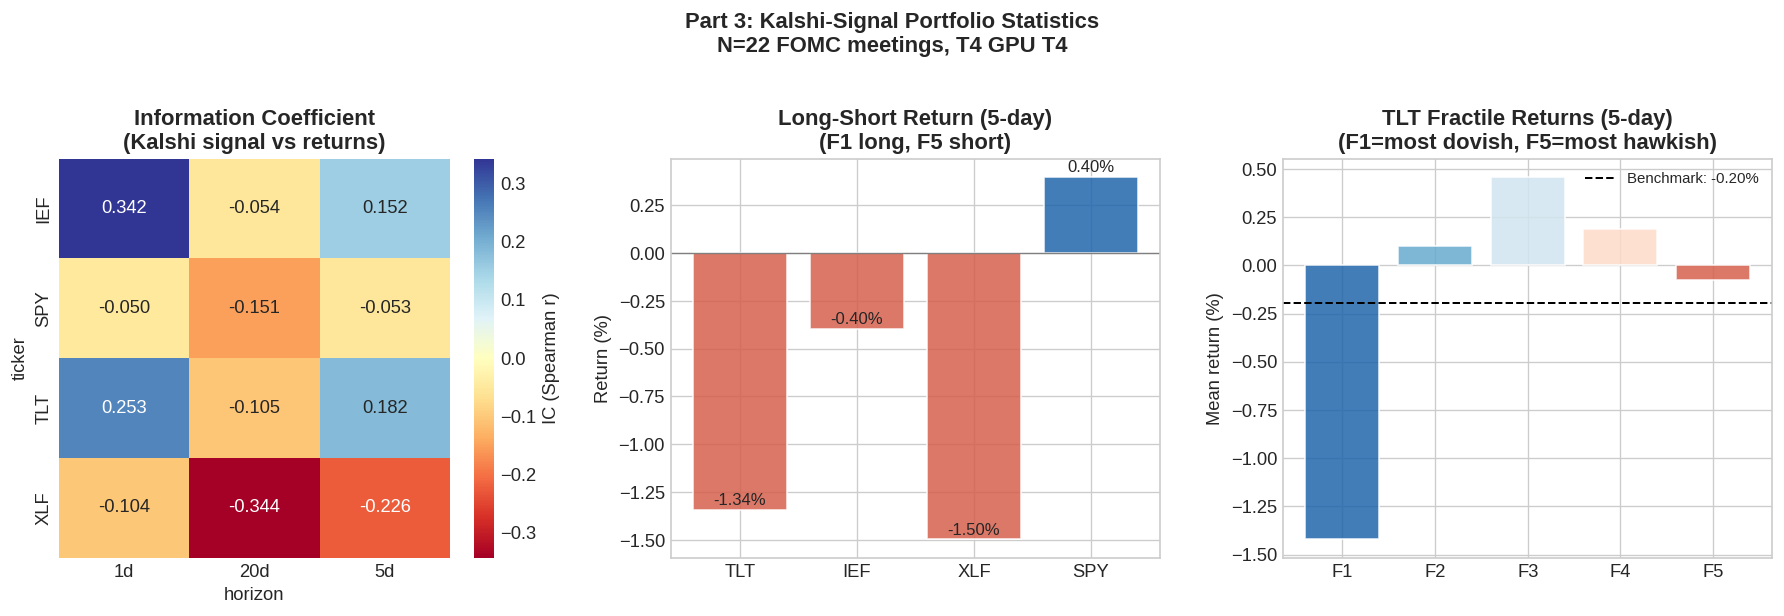

In [71]:
# ── Summary visualization: IC, Hit Rate, L/S Return ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: IC by ticker and horizon
ic_data = pd.DataFrame([
    {'ticker': t, 'horizon': f'{h}d', 'IC': ic_results[f'{t}_{h}d'][0]}
    for t in TICKERS for h in HORIZONS
])
ic_pivot = ic_data.pivot(index='ticker', columns='horizon', values='IC')
sns.heatmap(ic_pivot, ax=axes[0], cmap='RdYlBu', annot=True, fmt='.3f',
            center=0, cbar_kws={'label': 'IC (Spearman r)'})
axes[0].set_title('Information Coefficient\n(Kalshi signal vs returns)',
                   fontweight='bold')

# Panel 2: Long-Short returns at 5d
ls_vals  = [ls_results[f'{t}_5d']['ls_return'] * 100 for t in TICKERS]
ls_colors = ['#2166ac' if v > 0 else '#d6604d' for v in ls_vals]
axes[1].bar(TICKERS, ls_vals, color=ls_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Long-Short Return (5-day)\n(F1 long, F5 short)',
                   fontweight='bold')
axes[1].set_ylabel('Return (%)')
for i, v in enumerate(ls_vals):
    axes[1].text(i, v + 0.01, f'{v:.2f}%', ha='center', va='bottom', fontsize=10)

# Panel 3: Fractile return chart for TLT 5d
tlt_fractiles = [results['TLT_5d']['fractiles'].get(f, np.nan) * 100
                 for f in ['F1','F2','F3','F4','F5']]
bench_tlt = results['TLT_5d']['benchmark'] * 100
axes[2].bar(['F1','F2','F3','F4','F5'], tlt_fractiles,
            color=['#2166ac','#67a9cf','#d1e5f0','#fddbc7','#d6604d'],
            alpha=0.85, edgecolor='white')
axes[2].axhline(bench_tlt, color='black', linestyle='--', linewidth=1.2,
                label=f'Benchmark: {bench_tlt:.2f}%')
axes[2].set_title('TLT Fractile Returns (5-day)\n(F1=most dovish, F5=most hawkish)',
                   fontweight='bold')
axes[2].set_ylabel('Mean return (%)')
axes[2].legend(fontsize=9)

plt.suptitle('Part 3: Kalshi-Signal Portfolio Statistics\nN=22 FOMC meetings, T4 GPU T4',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_PATH + 'fig12_portfolio_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# ── Final summary table ───────────────────────────────────────────────────────
print("\n")
print("=" * 70)
print("PART 3 SUMMARY — ALL STATISTICS")
print("=" * 70)
print(f"Signal: Kalshi T-7 implied expected rate change (bps)")
print(f"N meetings: {len(port_df)}  |  Quintile N: ~{len(port_df)//5}")
print()
print(f"{'Metric':<40} {'TLT':>8} {'IEF':>8} {'XLF':>8} {'SPY':>8}")
print('-' * 75)

# IC at 5d
row = "IC (5d Spearman r)"
vals = [ic_results[f'{t}_5d'][0] for t in TICKERS]
print(f"{row:<40} " + " ".join(f"{v:>8.4f}" for v in vals))

# IC at 20d
row = "IC (20d Spearman r)"
vals = [ic_results[f'{t}_20d'][0] for t in TICKERS]
print(f"{row:<40} " + " ".join(f"{v:>8.4f}" for v in vals))

# L/S return 5d
row = "L/S return (5d)"
vals = [ls_results[f'{t}_5d']['ls_return']*100 for t in TICKERS]
print(f"{row:<40} " + " ".join(f"{v:>7.2f}%" for v in vals))

# L/S return 20d
row = "L/S return (20d)"
vals = [ls_results[f'{t}_20d']['ls_return']*100 for t in TICKERS]
print(f"{row:<40} " + " ".join(f"{v:>7.2f}%" for v in vals))

# Pseudo-Sharpe 5d
row = "Pseudo-Sharpe (5d, ~8 mtgs/yr)"
vals = [ls_results[f'{t}_5d']['sharpe'] for t in TICKERS]
print(f"{row:<40} " + " ".join(f"{v:>8.3f}" if not np.isnan(v) else f"{'N/A':>8}" for v in vals))

# IR
row = "IR (annual IC mean/std)"
vals = [ir_results[f'{t}_5d'] for t in TICKERS]
print(f"{row:<40} " + " ".join(f"{v:>8.3f}" if not np.isnan(v) else f"{'N/A':>8}" for v in vals))

print()
print("Key interpretation:")
print("  Negative IC for TLT = correct direction (dovish signal → bond rally)")
print("  Positive L/S for TLT = dovish meetings outperform hawkish meetings")
print("  N=22 meetings: results are directional, not statistically definitive")



PART 3 SUMMARY — ALL STATISTICS
Signal: Kalshi T-7 implied expected rate change (bps)
N meetings: 22  |  Quintile N: ~4

Metric                                        TLT      IEF      XLF      SPY
---------------------------------------------------------------------------
IC (5d Spearman r)                         0.1820   0.1525  -0.2256  -0.0533
IC (20d Spearman r)                       -0.1054  -0.0539  -0.3435  -0.1508
L/S return (5d)                            -1.34%   -0.40%   -1.50%    0.40%
L/S return (20d)                            0.57%    0.14%   -1.98%    0.14%
Pseudo-Sharpe (5d, ~8 mtgs/yr)             -0.620   -0.540   -1.036    0.265
IR (annual IC mean/std)                     0.573    0.428   -0.482   -0.290

Key interpretation:
  Negative IC for TLT = correct direction (dovish signal → bond rally)
  Positive L/S for TLT = dovish meetings outperform hawkish meetings
  N=22 meetings: results are directional, not statistically definitive
